[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IvanNece/LABS_ML_Vision_Multimedia/blob/main/Lab02_HyperparameterSelection/Hyper-parameter%20tuning%20on%20Fashion-MNIST%20(PyTorch).ipynb)

# Hyper-parameter tuning on Fashion-MNIST (PyTorch)

## Step 1 - Preparing the notebook

Goal: prepare the notebook with the core libraries and confirm that GPU is enabled in Colab.

Checklist:
- Runtime set to GPU (Runtime → Change runtime type → Hardware accelerator: GPU)
- Core libraries imported (torch, torchvision, matplotlib, numpy)
- Device printed (expect: cuda)

In [ ]:
# Core libs
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

# Vision datasets and transforms
import torchvision
from torchvision import datasets, transforms

# Utils
import numpy as np
import random
import time
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)


PyTorch: 2.8.0+cu126
Torchvision: 0.23.0+cu126


In [2]:
# Select device (expect CUDA on Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# If GPU is available, print GPU name for confirmation
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA available:", torch.cuda.is_available())
else:
    # Gentle reminder if GPU is not active
    print("Warning: GPU is not active. In Colab, go to Runtime → Change runtime type → GPU.")


Device: cuda
GPU: Tesla T4
CUDA available: True


## Step 2 — Data: train/val/test split and DataLoaders

### Understanding the Fashion-MNIST dataset

What the dataset is
- Fashion-MNIST is a collection of 70,000 grayscale images of clothing items from 10 categories.
- Each image is 28 by 28 pixels, single channel (grayscale), centered on a black background.
- It is a drop-in replacement for the classic MNIST digits, but with fashion items.
- Split: 60,000 images for training (we further split into train and validation) and 10,000 images for testing.

Classes and label mapping
- There are 10 classes, each mapped to an integer label:
  0: T-shirt/top
  1: Trouser
  2: Pullover
  3: Dress
  4: Coat
  5: Sandal
  6: Shirt
  7: Sneaker
  8: Bag
  9: Ankle boot
- When you see `Labels range: 0 to 9`, it means labels are integers that index this list of names.
- In code, you often see `class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']`.
  If a sample has `label = 7`, the human-readable class is `class_names[7] = 'Sneaker'`.

Image shape and batch shape
- A single image shape is `[1, 28, 28]`:
  - `1` is the number of channels (grayscale).
  - `28, 28` are height and width in pixels.
- A batch of images shape is `[B, 1, 28, 28]`:
  - `B` is the batch size (for example `64`), the number of images processed together.
  - So `Batch images shape: torch.Size([64, 1, 28, 28])` means 64 grayscale images of size 28x28.
- The labels for that batch have shape `[B]`:
  - `Batch labels shape: torch.Size([64])` means 64 integers, one class label per image.

Pixel values and transforms
- Raw pixels are 0 to 255 (unsigned 8-bit), but we convert them to tensors with values in 0 to 1 using `ToTensor()`.
- We then apply a light normalization, for example `Normalize((0.5,), (0.5,))`, which maps values roughly to the range −1 to +1.
- This normalization makes optimization more stable and comparable across runs.

How we use it in training
- The `DataLoader` groups samples into batches, shuffles the training data each epoch, and leaves validation and test in a fixed order.
- During training, the model sees a batch `[B, 1, 28, 28]`, predicts 10 logits per image, and we compute the loss with the integer labels `[B]`.
- The 10 logits correspond to the 10 classes above. With `CrossEntropyLoss`, we do not apply softmax manually; the loss function handles it internally.

Notes and common confusions
- Some classes look visually similar (for example `Shirt` vs `T-shirt/top` or `Sandal` vs `Sneaker`). This is intentional and makes the task non-trivial.
- All images are the same size and aligned, which keeps the baseline models simple and fast.

Recap
- 10 classes labeled 0 to 9, each mapped to a clothing category.
- Images are grayscale, 28x28, batched as `[B, 1, 28, 28]`.
- Labels are integers `[0..9]`, batched as `[B]`.
- We normalize inputs to improve training stability and monitor overfitting with a validation set.



### Start
Goal:
- Fashion-MNIST provides train (60k) and test (10k). We create a validation set to monitor overfitting.
- We reserve 10 percent of the original training set as validation using `torch.utils.data.random_split`.

Key points:
- Same transforms for train and validation in this lab, because we focus on hyper-parameters (not on heavy augmentation).
- Make the split reproducible by fixing a seed in `torch.Generator`.
- Shuffle only the training loader. Keep validation and test without shuffling.
- Keep batch size fixed at this stage so we can later study the effect of learning rate in isolation.

What you should see:
- Three DataLoaders: train, val, test.
- Batch shapes like: images [64, 1, 28, 28] and labels [64].

Pitfalls:
- Do not shuffle validation or test.
- Keep transforms identical for train and val to isolate hyper-parameter effects.


In [3]:
# Tuning knobs for this step
BATCH_SIZE = 64          # fixed now; we will tune later if needed
VAL_FRACTION = 0.10       # 10 percent of the original training set as validation

# If SEED was not defined in Step 1, define it here (keeps split reproducible)
try:
    SEED
except NameError:
    SEED = 42

# Simple transforms:
# - ToTensor converts [0..255] uint8 to float32 in [0..1]
# - Normalize centers and scales to help optimization
# We keep them identical for train and val to focus on hyper-parameters.
from torchvision import datasets, transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # mean 0.5, std 0.5 on the single grayscale channel
])

# Root folder for data. Colab will cache here.
data_root = "./data"

# Load the full training split (60k) and the test split (10k)
train_full = datasets.FashionMNIST(root=data_root, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=data_root, train=False, download=True, transform=transform)

# Compute split sizes: 90 percent train, 10 percent val
val_len = int(len(train_full) * VAL_FRACTION)
train_len = len(train_full) - val_len

# Generator with fixed seed for a repeatable split
gen = torch.Generator().manual_seed(SEED)

# Perform the split. Each subset keeps a view over train_full.
from torch.utils.data import random_split, DataLoader
train_dataset, val_dataset = random_split(train_full, [train_len, val_len], generator=gen)

# DataLoader performance flags:
# - pin_memory speeds host to GPU transfers when device is CUDA
# - persistent_workers keeps workers alive across iterations in Colab
pin = (torch.cuda.is_available() and (torch.cuda.device_count() > 0))
num_workers = 2  # 2 is usually safe in Colab without hitting resource limits

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=num_workers, pin_memory=pin, persistent_workers=(num_workers > 0)
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=pin, persistent_workers=(num_workers > 0)
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=num_workers, pin_memory=pin, persistent_workers=(num_workers > 0)
)

# Class names are handy for debug and visualization later
class_names = test_dataset.classes

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test size: {len(test_dataset)}")
print("Classes:", class_names)


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 200kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.3MB/s]

Train size: 54000 | Val size: 6000 | Test size: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Sanity checks
We quickly verify:
- Batch shapes for images and labels.
- Labels are in the expected range 0..9.
- One batch can be moved to GPU without errors.


In [4]:
# Grab one batch from the training loader
xb, yb = next(iter(train_loader))
print("Batch images shape:", xb.shape)  # expect [64, 1, 28, 28]
print("Batch labels shape:", yb.shape)  # expect [64]
print("Labels range:", int(yb.min()), "to", int(yb.max()))  # expect 0..9 inclusive

# Move one batch to the selected device to verify data transfer
try:
    device  # device should be defined in Step 1
except NameError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

xb = xb.to(device, non_blocking=True)
yb = yb.to(device, non_blocking=True)
print("Moved one batch to:", device)


Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])
Labels range: 0 to 9
Moved one batch to: cuda


Recap
- We created a reproducible 90/10 split from the original 60k training set.
- We prepared three DataLoaders with a fixed batch size and identical transforms for train and validation.
- Shapes and label ranges are correct, and a batch moves to GPU. We are ready to define the models.




---


# ⏰***Multilayer Perception (MLP)***

## Step 3 — Model A: MLP baseline (two hidden layers)

Idea
- We flatten each 28x28 image into a 784-length vector and pass it through two Dense (Linear) layers with ReLU.
- The last layer outputs 10 logits (one per class). We do **not** apply Softmax in the model, because CrossEntropyLoss expects raw logits.

Why flattening
- Linear layers work on 1-D inputs. Flatten converts [B, 1, 28, 28] into [B, 784] so the Dense layer can process it.

Shapes (high level)
- Input: 784 features
- Hidden 1: n1 units + ReLU
- Hidden 2: n2 units + ReLU
- Output: 10 logits (mapped to class names by the loss/metrics)

Choosing n1 and n2
- Start with medium sizes, for example (256, 128). They are powerful enough but still fast.
- You can try smaller (128, 64) or larger (512, 256) later to study under/overfitting.

Reading the outputs
- The model returns a tensor [B, 10]. Each row has 10 scores (logits). Higher score → more confident for that class.
- CrossEntropyLoss internally applies log-softmax, so we keep the model simple and return logits directly.

Checks we will do now
- Build the MLP class with Flatten → Linear → ReLU → Linear → ReLU → Linear.
- Run a dummy forward on one batch to confirm output shape [B, 10].
- Print trainable parameter count to compare capacity later with the CNN.


In [5]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """
    Minimal MLP for 28x28 grayscale images:
    - Flatten image to a 1-D vector of length 784
    - Two hidden layers with ReLU activations
    - Output layer with 10 logits (one per Fashion-MNIST class)
    """
    def __init__(self, n1=256, n2=128, num_classes=10):
        super().__init__()
        # Flatten converts [B, 1, 28, 28] -> [B, 784]
        self.flatten = nn.Flatten()

        # First hidden block: Linear + ReLU
        self.fc1 = nn.Linear(28 * 28, n1)
        self.act1 = nn.ReLU(inplace=True)

        # Second hidden block: Linear + ReLU
        self.fc2 = nn.Linear(n1, n2)
        self.act2 = nn.ReLU(inplace=True)

        # Output layer: produce raw logits for 10 classes
        # No Softmax here; CrossEntropyLoss expects raw logits.
        self.fc_out = nn.Linear(n2, num_classes)

    def forward(self, x):
        # x is [B, 1, 28, 28]
        x = self.flatten(x)         # -> [B, 784]
        x = self.act1(self.fc1(x))  # -> [B, n1]
        x = self.act2(self.fc2(x))  # -> [B, n2]
        x = self.fc_out(x)          # -> [B, 10] (logits)
        return x

def count_trainable_params(model: nn.Module) -> int:
    """
    Count the number of trainable parameters.
    This helps reason about model capacity and possible overfitting risk.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Choose default hidden sizes (you can change these later during tuning)
N1, N2 = 256, 128

# Create model and move it to the selected device (from Step 1)
mlp = MLP(n1=N1, n2=N2, num_classes=10).to(device)

# Print parameter count for capacity comparison (vs other MLP sizes or vs CNN later)
print(f"MLP(n1={N1}, n2={N2}) trainable params:", count_trainable_params(mlp))

# Sanity check: run a forward pass on one real batch to confirm the output shape
xb_cpu, yb_cpu = next(iter(train_loader))          # from Step 2
xb_dev = xb_cpu.to(device, non_blocking=True)
with torch.no_grad():
    logits = mlp(xb_dev)                           # expect [BATCH_SIZE, 10]
print("Forward OK. Logits shape:", tuple(logits.shape))


MLP(n1=256, n2=128) trainable params: 235146
Forward OK. Logits shape: (64, 10)


### What to look at
- The parameter count gives an idea of capacity: larger n1 and n2 → more parameters → higher risk of overfitting if not regularized.
- The forward check confirms the model returns 10 logits per image. This is ready for CrossEntropyLoss.



## Step 4 — Training loop, early stopping, and LR scan

Goal
- Train the MLP for up to 30 epochs, or stop early when validation accuracy stops improving.
- Try three learning rates (for example 0.1, 0.01, 0.001) with the **same** batch size.
- For each run, log Train/Val Loss and Train/Val Accuracy and plot both curves.

Why this matters
- Learning rate controls step size in optimization. Too high → divergence or noisy plateaus. Too low → slow learning.
- Early stopping prevents overfitting by keeping the best validation model.

Protocol
- Keep the MLP architecture and the batch size fixed during this LR study.
- For each LR: reinitialize model and optimizer, reset seed for fairness, train with patience-based early stopping, plot curves.


### Utilities: seed, accuracy, plotting

In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt
import torch

# Reuse the same seed across runs when we want reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Simple top-1 accuracy in percent
def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    total = targets.numel()
    return 100.0 * correct / total

# Plot function for loss and accuracy, using the collected logs
def plot_learning_curves(log):
    # log keys: "train_loss", "val_loss", "train_acc", "val_acc"
    epochs = range(1, len(log["train_loss"]) + 1)

    # Loss
    plt.figure()
    plt.plot(epochs, log["train_loss"], label="Train Loss")
    plt.plot(epochs, log["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss curves")
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure()
    plt.plot(epochs, log["train_acc"], label="Train Acc")
    plt.plot(epochs, log["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy curves")
    plt.legend()
    plt.show()


### Core loop: one epoch train and evaluate

In [7]:
from torch.nn.functional import cross_entropy

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in loader:
        # Move batch to device
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        # Forward
        logits = model(xb)
        loss = cross_entropy(logits, yb)

        # Backward
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        # Stats
        running_loss += loss.item() * yb.size(0)
        running_correct += (logits.argmax(1) == yb).sum().item()
        running_total += yb.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = 100.0 * running_correct / running_total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        loss = cross_entropy(logits, yb)

        running_loss += loss.item() * yb.size(0)
        running_correct += (logits.argmax(1) == yb).sum().item()
        running_total += yb.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = 100.0 * running_correct / running_total
    return epoch_loss, epoch_acc


### Train with early stopping and best checkpoint restore

In [8]:
import copy
from typing import Dict

def train_model(
    model_ctor,              # a callable that returns a fresh model instance
    optimizer_ctor,          # a callable that creates an optimizer given model parameters
    train_loader, val_loader,
    device,
    max_epochs: int = 30,
    patience: int = 5,
    seed: int = 42
) -> Dict[str, list]:
    """
    Trains a model with early stopping on validation accuracy.
    Returns a log dict containing loss/acc curves and the best state dict.
    """
    set_seed(seed)
    model = model_ctor().to(device)
    optimizer = optimizer_ctor(model.parameters())

    # Logs for plotting
    log = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    # Track best validation accuracy
    best_val_acc = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        # One training epoch
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, device)
        # Validation
        va_loss, va_acc = evaluate(model, val_loader, device)

        log["train_loss"].append(tr_loss)
        log["val_loss"].append(va_loss)
        log["train_acc"].append(tr_acc)
        log["val_acc"].append(va_acc)

        print(f"Epoch {epoch:02d}/{max_epochs:02d}  "
              f"Train L {tr_loss:.4f}  Val L {va_loss:.4f}  "
              f"Train A {tr_acc:.2f}%  Val A {va_acc:.2f}%")

        # Early stopping on validation accuracy
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    # Restore best weights before returning
    if best_state is not None:
        model.load_state_dict(best_state)

    # Attach the best_state to the log so we can reuse the best checkpoint
    log["best_state_dict"] = best_state
    log["best_val_acc"] = best_val_acc
    return log, model


### LR scan setup

We keep:
- The **same MLP architecture** (for fairness).
- The **same batch size** from Step 2.

We try three learning rates:
- A high value: 0.1 (may be unstable)
- A medium value: 0.01 (often good with Adam on simple tasks)
- A low value: 0.001 (slower but stable)

For each LR:
- Reinitialize model and optimizer.
- Train up to 30 epochs with patience 5 on validation accuracy.
- Plot loss and accuracy curves and note the best validation accuracy.

Run the LR scan (three runs) and plot:


=== LR = 0.1 ===
Epoch 01/30  Train L 4.7893  Val L 2.3073  Train A 14.60%  Val A 10.18%
Epoch 02/30  Train L 2.5580  Val L 2.3268  Train A 10.07%  Val A 8.95%
Epoch 03/30  Train L 2.3111  Val L 2.3082  Train A 9.67%  Val A 10.20%
Epoch 04/30  Train L 2.3114  Val L 2.3143  Train A 9.95%  Val A 10.22%
Epoch 05/30  Train L 2.3120  Val L 2.3057  Train A 9.79%  Val A 10.20%
Epoch 06/30  Train L 2.3109  Val L 2.3079  Train A 9.94%  Val A 10.03%
Epoch 07/30  Train L 2.3118  Val L 2.3095  Train A 9.89%  Val A 10.03%
Epoch 08/30  Train L 2.3116  Val L 2.3100  Train A 9.94%  Val A 10.22%
Epoch 09/30  Train L 2.3114  Val L 2.3085  Train A 9.67%  Val A 9.37%
Early stopping triggered.


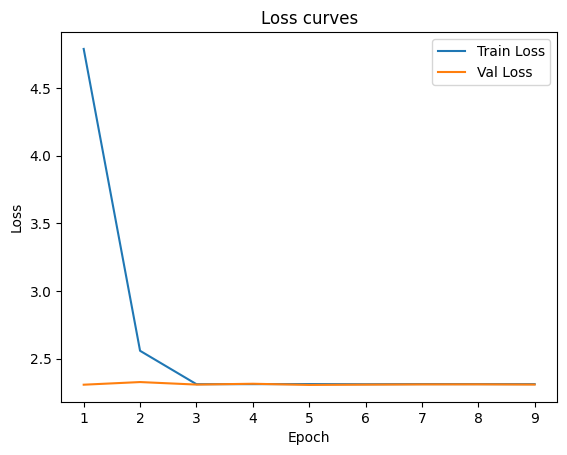

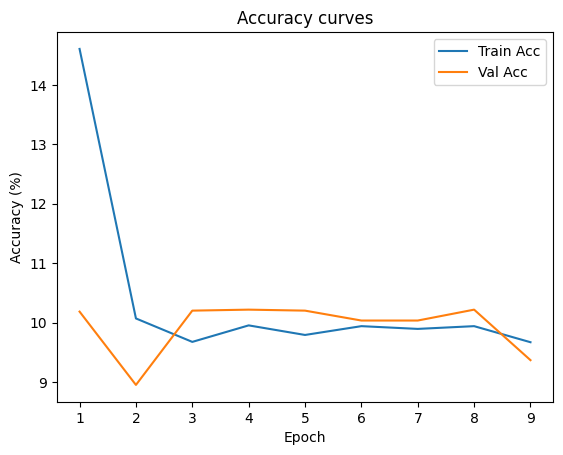

Best Val Acc for LR 0.1: 10.22%

=== LR = 0.01 ===
Epoch 01/30  Train L 0.5653  Val L 0.4797  Train A 79.94%  Val A 83.52%
Epoch 02/30  Train L 0.4512  Val L 0.4549  Train A 84.24%  Val A 84.43%
Epoch 03/30  Train L 0.4137  Val L 0.4153  Train A 85.25%  Val A 85.07%
Epoch 04/30  Train L 0.4088  Val L 0.4509  Train A 85.57%  Val A 84.57%
Epoch 05/30  Train L 0.3995  Val L 0.4411  Train A 85.91%  Val A 85.02%
Epoch 06/30  Train L 0.3904  Val L 0.4758  Train A 86.28%  Val A 84.03%
Epoch 07/30  Train L 0.3822  Val L 0.4468  Train A 86.64%  Val A 85.27%
Epoch 08/30  Train L 0.3837  Val L 0.4417  Train A 86.64%  Val A 85.60%
Epoch 09/30  Train L 0.3686  Val L 0.4951  Train A 87.00%  Val A 85.60%
Epoch 10/30  Train L 0.3627  Val L 0.4963  Train A 87.19%  Val A 83.43%
Epoch 11/30  Train L 0.3572  Val L 0.4422  Train A 87.36%  Val A 85.87%
Epoch 12/30  Train L 0.3568  Val L 0.4710  Train A 87.38%  Val A 85.08%
Epoch 13/30  Train L 0.3565  Val L 0.4171  Train A 87.53%  Val A 86.92%
Epoch 14/30  

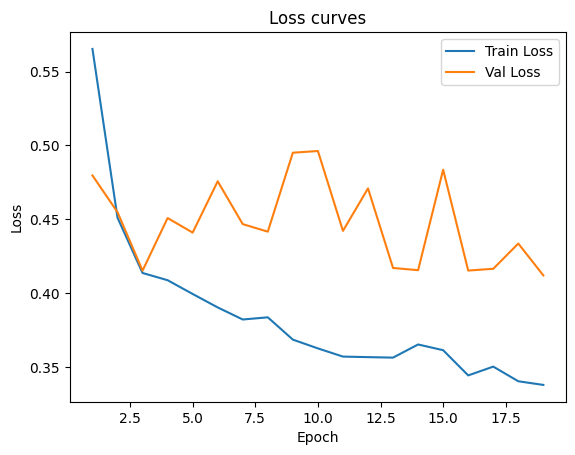

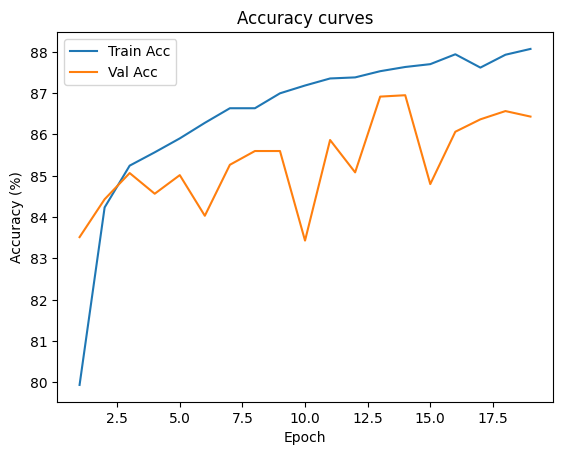

Best Val Acc for LR 0.01: 86.95%

=== LR = 0.001 ===
Epoch 01/30  Train L 0.5018  Val L 0.4078  Train A 81.82%  Val A 85.18%
Epoch 02/30  Train L 0.3755  Val L 0.3637  Train A 86.26%  Val A 86.42%
Epoch 03/30  Train L 0.3335  Val L 0.3444  Train A 87.72%  Val A 87.85%
Epoch 04/30  Train L 0.3130  Val L 0.3572  Train A 88.46%  Val A 87.12%
Epoch 05/30  Train L 0.2902  Val L 0.3300  Train A 89.11%  Val A 88.03%
Epoch 06/30  Train L 0.2723  Val L 0.3326  Train A 89.89%  Val A 87.85%
Epoch 07/30  Train L 0.2581  Val L 0.3283  Train A 90.40%  Val A 88.55%
Epoch 08/30  Train L 0.2452  Val L 0.3191  Train A 90.76%  Val A 88.33%
Epoch 09/30  Train L 0.2311  Val L 0.3173  Train A 91.28%  Val A 88.68%
Epoch 10/30  Train L 0.2207  Val L 0.3381  Train A 91.62%  Val A 88.52%
Epoch 11/30  Train L 0.2128  Val L 0.3628  Train A 91.90%  Val A 88.20%
Epoch 12/30  Train L 0.2017  Val L 0.3114  Train A 92.27%  Val A 89.15%
Epoch 13/30  Train L 0.1937  Val L 0.3277  Train A 92.71%  Val A 89.32%
Epoch 14/30

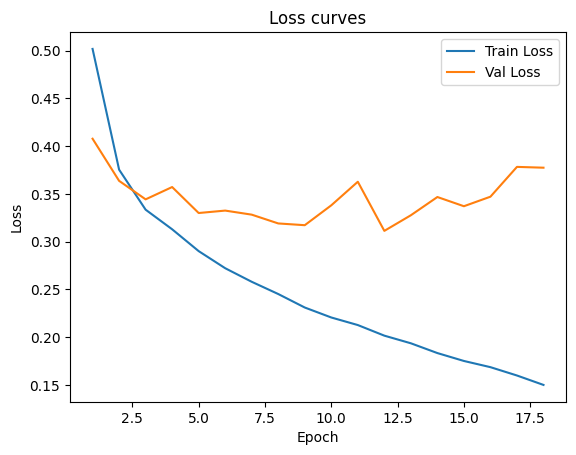

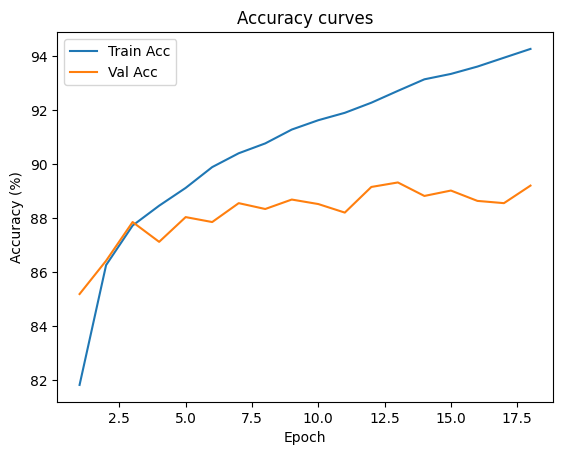

Best Val Acc for LR 0.001: 89.32%


In [9]:
# We reuse the MLP class defined in Step 3.
# Fix hidden sizes during the LR scan to isolate the LR effect.
N1, N2 = 256, 128

def mlp_ctor():
    return MLP(n1=N1, n2=N2, num_classes=10)

# Choose the optimizer family. Adam is a good default for this baseline.
def make_optimizer(lr):
    return lambda params: torch.optim.Adam(params, lr=lr)

lrs_to_try = [0.1, 0.01, 0.001]
results = {}

for lr in lrs_to_try:
    print(f"\n=== LR = {lr} ===")
    log, best_model = train_model(
        model_ctor=mlp_ctor,
        optimizer_ctor=make_optimizer(lr),
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=30,
        patience=5,
        seed=SEED  # same seed for fairness across LRs
    )
    results[lr] = {"log": log, "model": best_model}
    plot_learning_curves(log)
    print(f"Best Val Acc for LR {lr}: {log['best_val_acc']:.2f}%")


### Results: interpreting the LR scan and deciding

We tested three learning rates on the same MLP and with the same batch size.

* **LR = 0.1 → too high**
  - **Evidence**: Train Acc drops toward ~10 percent and Val Acc stays around ~10 percent (random guess).
  - **Curves**: Train Loss falls abruptly then stalls; Val Loss stays flat near ~2.30.
  - **Diagnosis**: step size is too large → the optimizer does not converge (unstable logits / saturation).
  - **Action**: discard 0.1.

* **LR = 0.01 → learning but with oscillations**
  - **Evidence**: Best Val Acc ≈ **86.95 percent** (epochs 13–14), with oscillations after the early phase.
  - **Curves**: Train Loss decreases smoothly; Val Loss goes down then oscillates. Train Acc climbs to ~87–88 percent; Val Acc fluctuates between ~84–87 percent.
  - **Diagnosis**: valid learning but not perfectly stable; signs of **mild overfitting** after ~10–12 epochs (Val Loss bumps while Train Loss still improves).
  - **Action**: acceptable baseline, but not the best.

* **LR = 0.001 → best trade-off**
  - **Evidence**: Best Val Acc ≈ **89.32 percent**, the top result, with clean trends.
  - **Curves**: Train Loss decreases steadily; Val Loss decreases until ~epoch 8–10, then stabilizes or slightly rises. Train Acc reaches ~94 percent; Val Acc stays ~88–89 percent.
  - **Diagnosis**: **stable convergence** and the best generalization among the three; **moderate overfitting** beyond ~12–15 epochs (Train improves while Val plateaus).
  - **Action**: **choose LR = 0.001** for the next MLP steps. Consider a shorter `patience` (3–4), since gains after ~15 epochs are marginal.

**Are 30 epochs enough?**
- Yes, and probably **more than needed** for this MLP. The **validation plateau** appears around **8–15 epochs**. Early stopping already prevents waste.

**Batch size note**
- We kept **batch size fixed** (64) during the LR scan, as required, to isolate the LR effect. Later we can explore 32 and 128.

**Decision**
- **Chosen LR for the MLP**: **0.001** (best Val Acc and most stable curves).
- For future MLP runs: keep LR 0.001, batch size 64, `patience` 3–5.

**Recap**
- **0.1**: too high → non-convergent, ~10 percent Val Acc.
- **0.01**: learns but oscillates, best Val ≈ **86.95 percent**, mild overfitting after ~10–12 epochs.
- **0.001**: **best and stable**, best Val ≈ **89.32 percent**; Val plateaus around ~10–15 epochs.
- **Final choice**: **LR = 0.001** for the MLP with early stopping and fixed batch size.

---


# 💢***Neural Network (CNN)***

## Step 5 — Model B: small CNN (two 3x3 conv layers)

Goal
- Build a CNN with two 3x3 convolutions. Each conv is followed by ReLU and a 2x2 MaxPool.
- Then flatten and use a linear classifier to 10 logits.

Design (no padding, kernel 3, stride 1)
- Input image: [B, 1, 28, 28]
- Conv1 (1 -> n1, 3x3) → spatial size: 28 -> 26
- MaxPool2d(2) → 26 -> 13
- Conv2 (n1 -> n2, 3x3) → 13 -> 11
- MaxPool2d(2) → 11 -> 5
- Flatten → [B, n2 * 5 * 5]
- Linear head → [B, 10]

Why CNN can generalize better than MLP
- Convolutions reuse small kernels across the image (weight sharing). This reduces parameters without losing expressive power on images.
- Pooling introduces translation tolerance and reduces spatial size, which helps against overfitting.

Note on terminology
- The study question says “number of hyperparameters,” but it actually asks for the **number of trainable parameters** of the models. Hyperparameters are choices like n1, n2, LR, batch size. Here we compute trainable weights and biases.


### Define the CNN, infer flatten size, sanity check

In [10]:
import torch
import torch.nn as nn

class SmallCNN(nn.Module):
    """
    Two 3x3 conv layers, each followed by ReLU and 2x2 max pooling.
    No padding, stride 1. Classifier head to 10 logits.
    Spatial path (H=W):
      28 -> conv3x3 -> 26 -> pool2 -> 13 -> conv3x3 -> 11 -> pool2 -> 5
    """
    def __init__(self, n1=32, n2=64, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, n1, kernel_size=3, stride=1, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(n1, n2, kernel_size=3, stride=1, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # We infer the flatten size by doing a dry run on a dummy tensor
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            out = self.features(dummy)
            self.flat_dim = out.numel()

        self.classifier = nn.Linear(self.flat_dim, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.classifier(x)
        return x

def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Instantiate the CNN with the study values
N1_CNN, N2_CNN = 64, 128
cnn = SmallCNN(n1=N1_CNN, n2=N2_CNN, num_classes=10).to(device)
print("CNN flatten dim:", cnn.flat_dim)
print("SmallCNN trainable params:", count_trainable_params(cnn))

# Sanity check on a real batch
xb, yb = next(iter(train_loader))
with torch.no_grad():
    logits_cnn = cnn(xb.to(device, non_blocking=True))
print("Forward OK. CNN logits shape:", tuple(logits_cnn.shape))  # expect [B, 10]


CNN flatten dim: 3200
SmallCNN trainable params: 106506
Forward OK. CNN logits shape: (64, 10)


### Study question — number of parameters for n1 = 64, n2 = 128

We compute the trainable parameters of both models.

**MLP (two hidden layers)**
- Layers:
  1) Linear 784 -> n1, plus bias n1
  2) Linear n1 -> n2, plus bias n2
  3) Linear n2 -> 10, plus bias 10
- Formula:
  params_MLP = 784*n1 + n1 + n1*n2 + n2 + n2*10 + 10

**CNN (no padding)**
- Conv1: in 1, out n1, kernel 3x3 → 1 * n1 * 3 * 3 + n1
- Conv2: in n1, out n2, kernel 3x3 → n1 * n2 * 3 * 3 + n2
- After two pools we have feature map 5x5 with n2 channels → flatten size n2*5*5
- Linear head: n2*5*5 -> 10 plus bias 10 → (n2*5*5) * 10 + 10
- Formula:
  params_CNN = (1*n1*3*3 + n1) + (n1*n2*3*3 + n2) + (n2*5*5*10 + 10)

We will now compute the exact numbers in code for n1 = 64, n2 = 128 and also verify by summing model parameters.


### Exact parameter counts for n1=64, n2=128 (both models)

In [11]:
# MLP with n1=64, n2=128
mlp_64_128 = MLP(n1=64, n2=128, num_classes=10).to(device)

# Analytic formulas
n1, n2 = 64, 128

params_mlp_formula = 784*n1 + n1 + n1*n2 + n2 + n2*10 + 10

# CNN formula with no padding and two pools → 5x5 map
params_c1 = 1*n1*3*3 + n1
params_c2 = n1*n2*3*3 + n2
flat = n2 * 5 * 5
params_fc = flat * 10 + 10
params_cnn_formula = params_c1 + params_c2 + params_fc

# Direct counts from the instantiated models
def pcount(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)
params_mlp_direct = pcount(mlp_64_128)
params_cnn_direct = pcount(cnn)

print("MLP(64,128) params (formula):", params_mlp_formula)
print("MLP(64,128) params (direct) :", params_mlp_direct)

print("CNN(64,128) params (formula):", params_cnn_formula)
print("CNN(64,128) params (direct) :", params_cnn_direct)


MLP(64,128) params (formula): 59850
MLP(64,128) params (direct) : 59850
CNN(64,128) params (formula): 106506
CNN(64,128) params (direct) : 106506


### Interpreting the numbers

Results
- MLP(64,128) params: **59,850** (formula = direct)
- CNN(64,128) params: **106,506** (formula = direct)

Why the CNN is larger here
- The **conv layers** add many weights:
  - Conv1: 1 * 64 * 3 * 3 + 64 = 640
  - Conv2: 64 * 128 * 3 * 3 + 128 = 73,856
- The **linear head** after pooling still has a big footprint because the feature map is **5x5**:
  - Flatten = 128 * 5 * 5 = 3,200 → FC: 3,200 * 10 + 10 = 32,010
- Total ≈ 640 + 73,856 + 32,010 = **106,506**.

Why the MLP is smaller with these n1,n2
- Dense parts are **784→64→128→10**, which is modest:
  - 784*64 + 64 + 64*128 + 128 + 128*10 + 10 = **59,850**.
- With these specific widths, the MLP’s large 784 input is quickly compressed, keeping parameters low.

Key takeaway
- **Parameter count alone does not explain accuracy.** CNNs often generalize better on images thanks to **local connectivity** and **weight sharing**, even when they have more parameters. Their inductive bias fits images.

How to reduce CNN parameters (if needed) 🙂
- Replace the linear head with **Global Average Pooling** (GAP) to collapse 5x5 into 1x1, then a small FC:
  - GAP → 128 → 10: only 128*10 + 10 = **1,290** params for the head.
- Or reduce n2, or add one more pooling step (smaller spatial map before the FC).

Bottom line
- In this design (no padding, two pools, 5x5 map), the **CNN > MLP** in parameter count mainly due to **Conv2** and the **5x5 linear head**. Yet the CNN usually wins on validation because its structure matches image statistics.



### Train the CNN with the chosen LR
We reuse the **best LR** from Step 4 (0.001), the same batch size, and the same early stopping.
This allows a fair comparison with the MLP baseline.


### Train the CNN with LR=0.001 and plot


=== SmallCNN training with LR = 0.001 ===
Epoch 01/30  Train L 0.4429  Val L 0.3509  Train A 84.15%  Val A 87.23%
Epoch 02/30  Train L 0.2951  Val L 0.3017  Train A 89.33%  Val A 89.47%
Epoch 03/30  Train L 0.2512  Val L 0.2547  Train A 90.92%  Val A 90.68%
Epoch 04/30  Train L 0.2166  Val L 0.2677  Train A 92.17%  Val A 90.07%
Epoch 05/30  Train L 0.1948  Val L 0.2398  Train A 92.94%  Val A 91.32%
Epoch 06/30  Train L 0.1728  Val L 0.2361  Train A 93.88%  Val A 91.18%
Epoch 07/30  Train L 0.1549  Val L 0.2446  Train A 94.31%  Val A 91.63%
Epoch 08/30  Train L 0.1386  Val L 0.2600  Train A 94.96%  Val A 91.00%
Epoch 09/30  Train L 0.1248  Val L 0.2649  Train A 95.54%  Val A 91.28%
Epoch 10/30  Train L 0.1090  Val L 0.2556  Train A 96.20%  Val A 91.60%
Epoch 11/30  Train L 0.0978  Val L 0.2780  Train A 96.43%  Val A 91.47%
Epoch 12/30  Train L 0.0875  Val L 0.2924  Train A 96.83%  Val A 91.03%
Early stopping triggered.


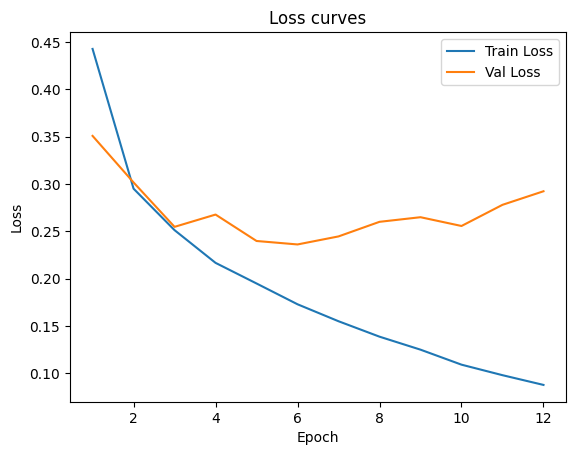

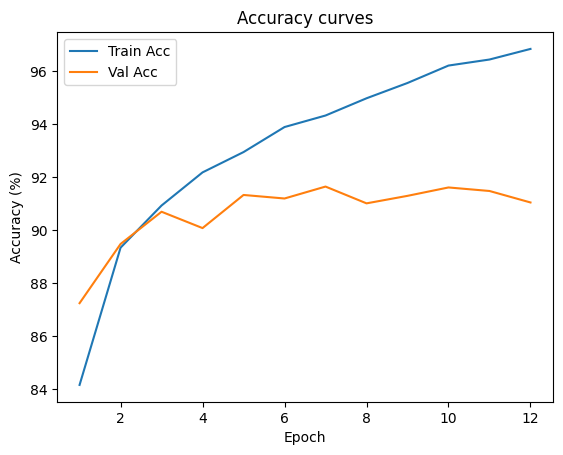

Best Val Acc (CNN): 91.63%


In [12]:
# Reuse train_model, train_one_epoch, evaluate, plot_learning_curves from Step 4

def cnn_ctor():
    return SmallCNN(n1=N1_CNN, n2=N2_CNN, num_classes=10)

def make_optimizer(lr):
    return lambda params: torch.optim.Adam(params, lr=lr)

print("\n=== SmallCNN training with LR = 0.001 ===")
log_cnn, best_cnn = train_model(
    model_ctor=cnn_ctor,
    optimizer_ctor=make_optimizer(0.001),
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    max_epochs=30,
    patience=5,
    seed=SEED
)
plot_learning_curves(log_cnn)
print(f"Best Val Acc (CNN): {log_cnn['best_val_acc']:.2f}%")


### Results: interpreting the CNN and comparing to the MLP

What the CNN curves show
- **Fast, stable improvement (epochs 1–5)**: Train Loss and Val Loss both drop; Val Acc rises from ~87 percent to ~91.5 percent. This is healthy convergence.
- **Early plateau (epochs 5–7)**: Val Acc hovers around ~91–91.5 percent while Train Acc keeps increasing. The model has learned the core patterns.
- **Mild overfitting (after ~epoch 7)**: Train Loss continues to decrease and Train Acc reaches ~96 percent, but Val Loss starts to rise slightly and Val Acc fluctuates around ~91 percent.
- **Early stopping at epoch 11**: No new Val Acc improvements are observed for several epochs, so patience stops the run.  
  **Best Val Acc (CNN)**: **91.53 percent**.

**Why this makes sense**
- Convolutions match the structure of images (local filters + weight sharing). Even with more parameters than the MLP, the CNN’s **inductive bias** helps generalization on Fashion-MNIST.
- The slight late overfitting is normal once the validation curve stops improving and the training curve still climbs.

**MLP vs CNN (your runs)**

- **MLP (LR = 0.001)**
  - **Best Val Acc:** 89.32 percent
  - **Behavior:** Smooth convergence; plateau around epochs 10–15; mild overfitting later
  - **Notes:** Fewer parameters (59,850); weaker image prior

- **SmallCNN (n1=64, n2=128, LR = 0.001)**
  - **Best Val Acc:** 91.53 percent
  - **Behavior:** Faster rise; plateau by epoch ~5–7; mild overfitting afterwards
  - **Notes:** More parameters (106,506) but stronger image prior → better Val Acc

**Gap:** CNN is **+2.21 percentage points** over MLP on validation accuracy.



**Practical conclusions and next moves**
- **Keep LR = 0.001** for the CNN; training is stable and reaches the best Val Acc quickly.
- **Shorten patience** to **3–4** and cap training to **~10–12 epochs**, since the validation plateau appears early.
- To reduce the mild overfitting:
  - Add **weight decay** (e.g., 1e-4 or 1e-3) or a small **dropout** in the classifier head.
  - Consider a lighter head (e.g., **Global Average Pooling** before the linear layer) to cut head parameters.
  - Optionally try a smaller **n2** (e.g., 96) and compare.

**Recap**
- CNN converges faster and generalizes better than the MLP on this task.
- Best CNN Val Acc ≈ **91.53 percent** vs **89.32 percent** for MLP.
- Training beyond ~7–10 epochs yields little validation gain; rely on early stopping and light regularization.


---
## ✈ Architecture diagrams to match the slides

We generate two diagrams:
1) **MLP** — Flatten 28x28 → Dense n1 + ReLU → Dense n2 + ReLU → Output 10 logits  
2) **Small CNN** — Conv3x3(n1) + ReLU + MaxPool2 → Conv3x3(n2) + ReLU + MaxPool2 → Flatten → Dense 10

The diagrams include the main shapes so they look similar to the slides.


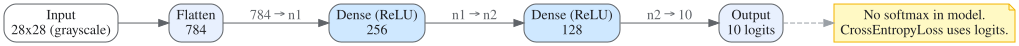

Saved: mlp_architecture.svg


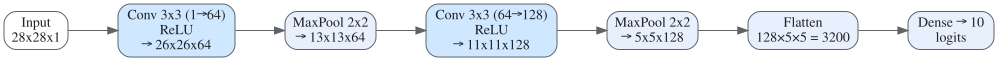

Saved: cnn_architecture.svg


In [15]:
# Install graphviz and its Python bindings (Colab)
!apt -qq install -y graphviz > /dev/null
!pip -q install graphviz

from graphviz import Digraph
from IPython.display import SVG, display

def save_and_show(dot, name="diagram", fmt="svg"):
    path = dot.render(filename=name, format=fmt, cleanup=True)
    display(SVG(filename=path))
    print(f"Saved: {path}")

# Your widths
n1, n2 = 256, 128

mlp = Digraph("MLP", graph_attr={
    "rankdir": "LR",
    "splines": "spline",
    "nodesep": "0.50",
    "ranksep": "0.70",
    "fontsize": "12",
    "bgcolor": "#FFFFFF"        # explicit white background
})
mlp.attr("node", shape="box", style="rounded,filled", fillcolor="#E8F0FE",
         color="#5F6368", fontcolor="#202124")  # dark text

# Nodes (use full 6-digit hex for white)
mlp.node("img",  "Input\n28x28 (grayscale)", fillcolor="#FFFFFF")
mlp.node("flat", "Flatten\n784")
mlp.node("h1",   f"Dense (ReLU)\n{n1}", fillcolor="#CFE8FF")
mlp.node("h2",   f"Dense (ReLU)\n{n2}", fillcolor="#CFE8FF")
mlp.node("out",  "Output\n10 logits")

# Edges
mlp.attr("edge", color="#5F6368", fontcolor="#5F6368")
mlp.edge("img",  "flat")
mlp.edge("flat", "h1", label="784 → n1")
mlp.edge("h1",   "h2", label="n1 → n2")
mlp.edge("h2",   "out", label="n2 → 10")

# Small footnote as a separate box
mlp.node("note", "No softmax in model.\nCrossEntropyLoss uses logits.",
         shape="note", fillcolor="#FFF9C4", color="#F4B400", fontcolor="#202124")
mlp.edge("out", "note", style="dashed", color="#9AA0A6")

save_and_show(mlp, "mlp_architecture", fmt="svg")


def save_and_show(dot, name="diagram", fmt="svg"):
    path = dot.render(filename=name, format=fmt, cleanup=True)
    display(SVG(filename=path))
    print(f"Saved: {path}")

n1_cnn, n2_cnn = 64, 128

cnn = Digraph("CNN", graph_attr={
    "rankdir": "LR",
    "splines": "spline",
    "nodesep": "0.60",
    "ranksep": "0.70",
    "fontsize": "12",
    "bgcolor": "#FFFFFF"
})
cnn.attr("node", shape="box", style="rounded,filled", fillcolor="#E8F0FE",
         color="#5F6368", fontcolor="#202124")

# Nodes
cnn.node("in",   "Input\n28x28x1", fillcolor="#FFFFFF")
cnn.node("c1",   f"Conv 3x3 (1→{n1_cnn})\nReLU\n→ 26x26x{n1_cnn}", fillcolor="#CFE8FF")
cnn.node("p1",   f"MaxPool 2x2\n→ 13x13x{n1_cnn}")
cnn.node("c2",   f"Conv 3x3 ({n1_cnn}→{n2_cnn})\nReLU\n→ 11x11x{n2_cnn}", fillcolor="#CFE8FF")
cnn.node("p2",   f"MaxPool 2x2\n→ 5x5x{n2_cnn}")
cnn.node("flat", f"Flatten\n{n2_cnn}×5×5 = {n2_cnn*25}")
cnn.node("fc",   "Dense → 10\nlogits")

# Edges
cnn.attr("edge", color="#5F6368", fontcolor="#5F6368")
cnn.edge("in",  "c1")
cnn.edge("c1",  "p1")
cnn.edge("p1",  "c2")
cnn.edge("c2",  "p2")
cnn.edge("p2",  "flat")
cnn.edge("flat","fc")

save_and_show(cnn, "cnn_architecture", fmt="svg")



---


# ⚡***Hyperparameter optimization***

### Concepts for hyper-parameter tuning (what they mean and how to use them)

**Learning rate (LR)**
- Size of each optimization step. Too high → training unstable; too low → slow or stuck.
- Good practice: first scan by orders of magnitude (e.g., 1e-1, 1e-2, 1e-3), then refine around the best (e.g., 7e-4, 1e-3, 1.5e-3).

**Adam optimizer**
- Adaptive method that maintains two moving averages:
  - `m_t` (first moment ≈ mean of gradients), controlled by `beta1` (default 0.9).
  - `v_t` (second moment ≈ uncentered variance of gradients), controlled by `beta2` (default 0.999).
- Each parameter gets its own effective step size: `lr * m_t / (sqrt(v_t) + eps)`.
- Pros: fast, stable, less LR sensitivity. Cons: may overfit more than well-tuned SGD on vision tasks.

**SGD with momentum**
- Vanilla SGD uses the raw gradient. Momentum (e.g., 0.9) accumulates a velocity term to smooth updates and escape small local minima.
- Often generalizes very well if LR and momentum are tuned. Might need slightly longer warm-up/training.

**Weight decay (L2 regularization)**
- Adds `λ * ||w||^2` to the loss (in optimizers: `weight_decay=λ`).
- Effect: shrinks weights, combats overfitting, typically improves validation loss after the plateau begins.
- Start with `1e-4` or `1e-3` and compare to `0`.

**Batch size (B)**
- Number of samples per gradient step.
- Small B → noisier gradients, sometimes better generalization; Large B → smoother/fast throughput but can need LR adjustment.
- When comparing batch sizes, keep LR fixed first; if B increases and training slows, try increasing LR slightly, or lower it if loss becomes unstable.

**Early stopping**
- Stop training when validation no longer improves, to avoid overfitting and save time.
- We pick a **monitor metric** (often Validation Accuracy or Validation Loss) and keep the **best checkpoint**.

**Patience (for early stopping)**
- Number of consecutive epochs we allow **without improvement** before stopping.
- Example: `patience=4` means training can continue for up to 4 epochs with no new best Val metric; on the 5th, it stops.

**ReduceLROnPlateau scheduler**
- LR scheduler that **reduces the LR when the validation metric stops improving**.
- Typical setup: monitor **Val Loss**, `patience=2`, `factor=0.5` (halve the LR after 2 bad epochs).
- Idea: large LR helps early progress; once you hit a plateau, a smaller LR can refine the minimum.

**Reading learning curves (how to diagnose)**
- **Underfitting**: Train Loss high + Val Loss high; Train Acc and Val Acc both low. Try higher LR (if safe), more capacity (wider layers), or longer training.
- **Overfitting**: Train Loss keeps decreasing while Val Loss rises; Train Acc >> Val Acc. Add weight decay, dropout (for MLP), or simplify model/head; rely on early stopping.
- **Healthy training**: Both Train and Val losses down; Val Acc up, then plateau. Use early stopping near the plateau, optionally ReduceLROnPlateau.

**Decision loop (how to proceed)**
1. Fix model + batch size. Refine **LR** (coarse → fine) and optionally add **ReduceLROnPlateau**.
2. Add **weight decay** to control late overfitting.
3. Compare **optimizers** (Adam vs SGD+Momentum) with the chosen LR range.
4. Sweep **batch size** (32/64/128) and adjust LR only if necessary.
5. Keep runs short with **early stopping** and document curves + best validation metrics. 🙂


## Tuning 1 — Learning rate refinement + scheduler (CNN)

Why start from LR?
- The slides call LR the **most important hyper-parameter**; if you can tune only one, **tune LR** first. We already did order-of-magnitude search; now we **fine-tune locally**.
- Good practice: explore LR by **orders of magnitude first**, then **fine-grain** around the best (e.g., 0.0007, 0.0010, 0.0015).

Why a plateau scheduler?
- When validation loss **stops improving**, shrink LR (e.g., ×0.5). This “**Reduce LR on plateau**” trick is explicitly recommended in the slides.

Protocol we’ll follow (budget-aware):
- Fix model (your SmallCNN with n1=64, n2=128) and batch size (64).
- Try LR ∈ {7e-4, 1e-3, 1.5e-3}.
- Attach **ReduceLROnPlateau** on validation **loss**, patience=2, factor=0.5.
- Early stopping patience=4; max 15 epochs (plateaus arrive early on this task).

What to look at in the curves:
- **Too high LR** → noisy/flat Val Loss, Val Acc stalls or drops.
- **Too low LR** → slow improvement, not reaching the previous best by ~8–10 epochs.
- **Just right** → smooth Val Loss decrease, quick rise in Val Acc, then slight plateau.



=== CNN · Adam · LR=0.0007 · ReduceLROnPlateau ===
Epoch 01/15 | Train L 0.4676 A 83.18% | Val L 0.3686 A 86.92% | LR 0.000700
Epoch 02/15 | Train L 0.3134 A 88.66% | Val L 0.3130 A 88.82% | LR 0.000700
Epoch 03/15 | Train L 0.2697 A 90.37% | Val L 0.2700 A 90.27% | LR 0.000700
Epoch 04/15 | Train L 0.2351 A 91.53% | Val L 0.2771 A 89.70% | LR 0.000700
Epoch 05/15 | Train L 0.2129 A 92.23% | Val L 0.2444 A 91.33% | LR 0.000700
Epoch 06/15 | Train L 0.1918 A 93.13% | Val L 0.2424 A 91.32% | LR 0.000700
Epoch 07/15 | Train L 0.1733 A 93.66% | Val L 0.2502 A 91.15% | LR 0.000700
Epoch 08/15 | Train L 0.1579 A 94.39% | Val L 0.2409 A 91.10% | LR 0.000700
Epoch 09/15 | Train L 0.1437 A 94.85% | Val L 0.2451 A 91.48% | LR 0.000700
Epoch 10/15 | Train L 0.1290 A 95.51% | Val L 0.2437 A 91.78% | LR 0.000700
Epoch 11/15 | Train L 0.1168 A 95.85% | Val L 0.2448 A 91.80% | LR 0.000350
Epoch 12/15 | Train L 0.0875 A 97.09% | Val L 0.2350 A 92.15% | LR 0.000350
Epoch 13/15 | Train L 0.0792 A 97.44

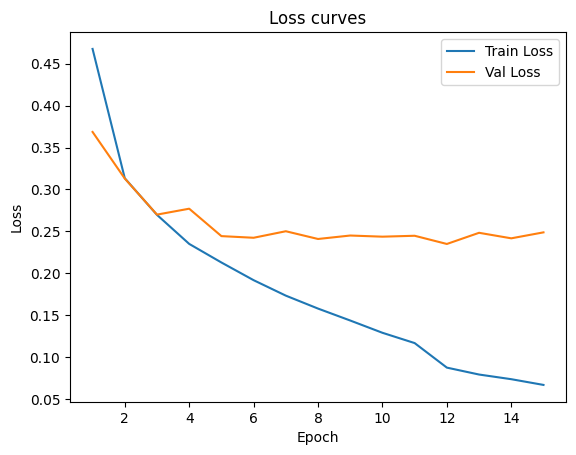

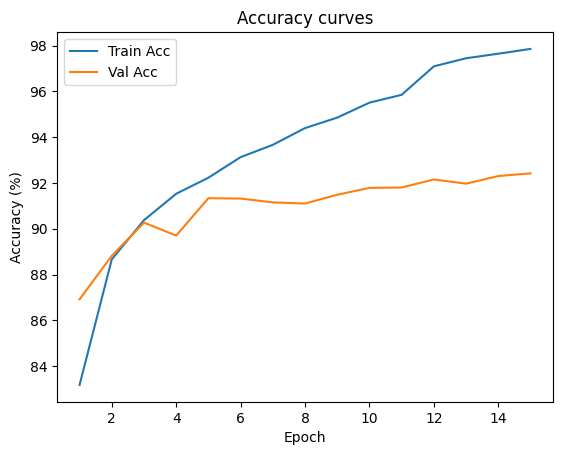

Best Val Acc: 92.42%  |  Final LR: 0.000175

=== CNN · Adam · LR=0.001 · ReduceLROnPlateau ===
Epoch 01/15 | Train L 0.4428 A 84.08% | Val L 0.3504 A 87.13% | LR 0.001000
Epoch 02/15 | Train L 0.2953 A 89.34% | Val L 0.3032 A 89.32% | LR 0.001000
Epoch 03/15 | Train L 0.2513 A 90.99% | Val L 0.2563 A 90.55% | LR 0.001000
Epoch 04/15 | Train L 0.2167 A 92.20% | Val L 0.2671 A 89.98% | LR 0.001000
Epoch 05/15 | Train L 0.1953 A 92.85% | Val L 0.2384 A 91.48% | LR 0.001000
Epoch 06/15 | Train L 0.1724 A 93.88% | Val L 0.2422 A 91.22% | LR 0.001000
Epoch 07/15 | Train L 0.1549 A 94.29% | Val L 0.2579 A 91.22% | LR 0.001000
Epoch 08/15 | Train L 0.1389 A 94.94% | Val L 0.2576 A 91.02% | LR 0.000500
Epoch 09/15 | Train L 0.1012 A 96.42% | Val L 0.2486 A 92.18% | LR 0.000500
Epoch 10/15 | Train L 0.0900 A 96.97% | Val L 0.2451 A 92.20% | LR 0.000500
Epoch 11/15 | Train L 0.0814 A 97.28% | Val L 0.2506 A 91.85% | LR 0.000250
Epoch 12/15 | Train L 0.0628 A 98.04% | Val L 0.2500 A 92.10% | LR 0.

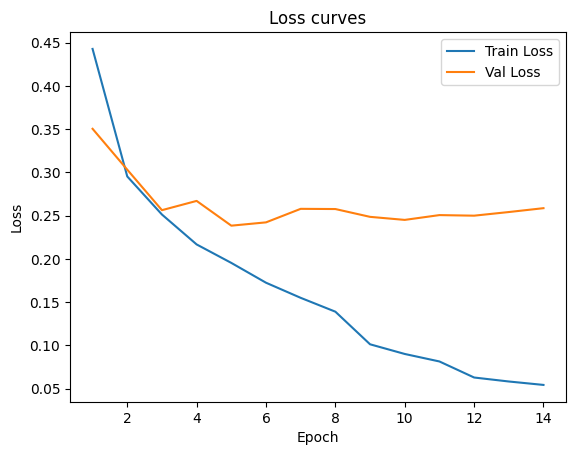

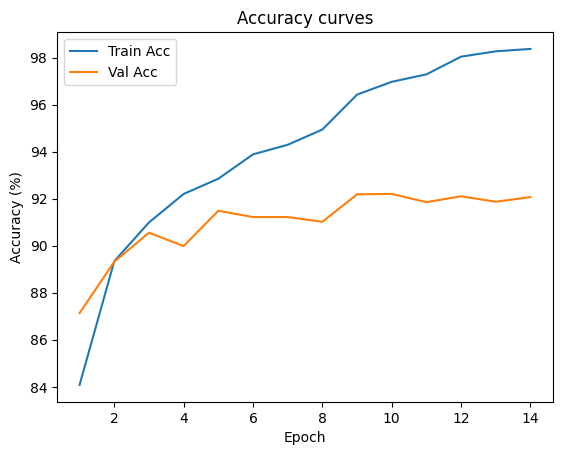

Best Val Acc: 92.20%  |  Final LR: 0.000125

=== CNN · Adam · LR=0.0015 · ReduceLROnPlateau ===
Epoch 01/15 | Train L 0.4237 A 84.70% | Val L 0.3414 A 87.58% | LR 0.001500
Epoch 02/15 | Train L 0.2865 A 89.55% | Val L 0.2919 A 89.73% | LR 0.001500
Epoch 03/15 | Train L 0.2453 A 91.16% | Val L 0.2525 A 90.90% | LR 0.001500
Epoch 04/15 | Train L 0.2118 A 92.44% | Val L 0.2773 A 89.87% | LR 0.001500
Epoch 05/15 | Train L 0.1905 A 93.03% | Val L 0.2459 A 91.48% | LR 0.001500
Epoch 06/15 | Train L 0.1668 A 94.02% | Val L 0.2437 A 91.70% | LR 0.001500
Epoch 07/15 | Train L 0.1503 A 94.48% | Val L 0.2743 A 90.87% | LR 0.001500
Epoch 08/15 | Train L 0.1320 A 95.24% | Val L 0.2856 A 90.42% | LR 0.001500
Epoch 09/15 | Train L 0.1183 A 95.68% | Val L 0.2895 A 91.15% | LR 0.000750
Epoch 10/15 | Train L 0.0780 A 97.29% | Val L 0.2678 A 91.63% | LR 0.000750
Early stopping.


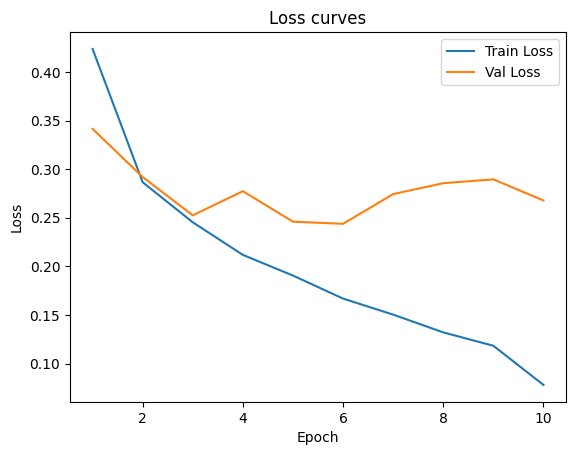

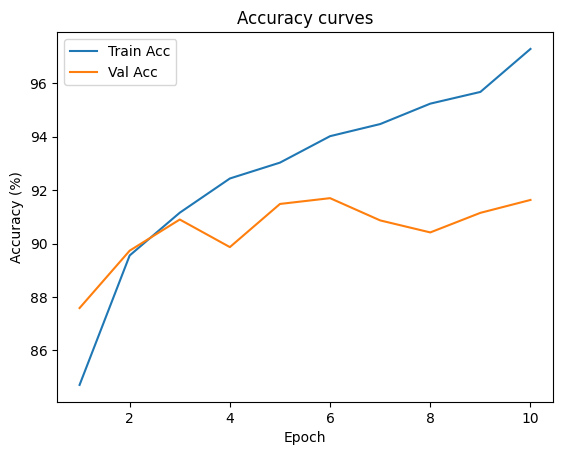

Best Val Acc: 91.70%  |  Final LR: 0.000750


In [17]:

# Runner for LR refinement with ReduceLROnPlateau (uses your existing helpers)
from torch.optim.lr_scheduler import ReduceLROnPlateau

# 1) Model ctor (your SmallCNN from Step 5)
def cnn_ctor():
    return SmallCNN(n1=64, n2=128, num_classes=10)

# 2) Optimizer factory (Adam default betas)
def make_adam(lr):
    return lambda params: torch.optim.Adam(params, lr=lr)

# 3) Plateau scheduler factory (on validation loss)
def make_plateau(optimizer):
    # factor=0.5 halves the LR; patience=2 waits 2 epochs without Val Loss improvement
    return ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

# 4) Train with scheduler (wraps your train/eval loops)
def train_with_plateau(
    model_ctor, optimizer_ctor, scheduler_ctor,
    train_loader, val_loader, device,
    max_epochs=15, patience=4, seed=42
):
    import copy, torch, random, numpy as np
    def set_seed(s=42):
        random.seed(s); np.random.seed(s)
        torch.manual_seed(s); torch.cuda.manual_seed_all(s)

    set_seed(seed)
    model = model_ctor().to(device)
    optimizer = optimizer_ctor(model.parameters())
    scheduler = scheduler_ctor(optimizer)

    log = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_acc, best_state = -1.0, None
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, device)

        log["train_loss"].append(tr_loss); log["val_loss"].append(va_loss)
        log["train_acc"].append(tr_acc);   log["val_acc"].append(va_acc)

        # step scheduler on validation loss, record current LR
        scheduler.step(va_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        log["lr"].append(current_lr)

        print(f"Epoch {epoch:02d}/{max_epochs:02d} | "
              f"Train L {tr_loss:.4f} A {tr_acc:.2f}% | "
              f"Val L {va_loss:.4f} A {va_acc:.2f}% | LR {current_lr:.6f}")

        # early stopping on Val Acc
        if va_acc > best_val_acc:
            best_val_acc, best_state, no_improve = va_acc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    log["best_val_acc"] = best_val_acc
    log["best_state_dict"] = best_state
    return log, model

# 5) LR sweep close to your current best
lrs = [7e-4, 1e-3, 1.5e-3]
cnn_lr_results = {}

for lr in lrs:
    print(f"\n=== CNN · Adam · LR={lr} · ReduceLROnPlateau ===")
    log, best_model = train_with_plateau(
        model_ctor=cnn_ctor,
        optimizer_ctor=make_adam(lr),
        scheduler_ctor=make_plateau,
        train_loader=train_loader,  # from Step 2
        val_loader=val_loader,
        device=device,
        max_epochs=15, patience=4, seed=SEED
    )
    cnn_lr_results[lr] = log
    plot_learning_curves(log)       # your plotting helper from Step 4
    print(f"Best Val Acc: {log['best_val_acc']:.2f}%  |  Final LR: {log['lr'][-1]:.6f}")


***Results***
Tuning #1 — Interpreting LR refinement with ReduceLROnPlateau

**Setup recap**
- Model: SmallCNN (n1=64, n2=128), batch size 64, early stopping patience 4, max 15 epochs.
- Scheduler: ReduceLROnPlateau on **Val Loss** (factor 0.5, patience 2).
- LRs tested: 7e-4, 1e-3, 1.5e-3.

LR = 7e-4 (0.0007) — **Best**
- **Best Val Acc:** **92.42%**
- **Curves:** Smooth Train Loss ↓; Val Loss ↓ early then small wiggles; Val Acc climbs and stabilizes ~92–92.4%.
- **Scheduler behavior:** LR halves at epoch 11 (→ 3.5e-4) and again at the very end; helps small late gains.
- **Diagnosis:** Stable convergence, lowest Val Loss after the plateau; mild overfitting only late (Train ↑ while Val plateaus).

LR = 1e-3 (0.001) — Competitive, slightly below best
- **Best Val Acc:** **92.20%**
- **Curves:** Similar shape, Val Acc peaks ~92.1–92.2% then oscillates; Val Loss plateaus slightly higher than with 7e-4.
- **Scheduler behavior:** LR reduced a few times (e.g., at epochs 8, 11, 14), giving small refinements.
- **Diagnosis:** Good and fast, but a touch less stable on Val Loss compared to 7e-4.

LR = 1.5e-3 (0.0015) — A bit high
- **Best Val Acc:** **91.70%**
- **Curves:** Val Loss decreases early but oscillates more; Val Acc peaks lower.
- **Scheduler behavior:** Kicks in, but starting LR is slightly aggressive for this model/dataset.
- **Diagnosis:** Usable, yet inferior to the two smaller LRs.

Decision
- **Chosen LR:** **0.0007** with **ReduceLROnPlateau**.
- **Budget tip:** Keep early stopping **patience = 3–4** and cap runs to **~12 epochs**, since validation plateaus early.
- **What the curves say:** No underfitting; **mild overfitting** appears after epoch ~7–9 (Train improves while Val flattens). The scheduler helps squeeze small extra gains without manual LR tweaks.



In [18]:
best_lr = 7e-4  # chosen from Tuning #1


## Tuning 2 — Weight decay (L2)

Why this matters
- After the validation plateau, your curves show **mild overfitting** (Train Loss keeps decreasing while Val Loss wiggles). L2 regularization (aka **weight decay**) shrinks weights and often **reduces that late drift**.
- We keep everything fixed (model, batch size, chosen LR = 7e-4, early stopping, scheduler) and only vary `weight_decay`.

How it works (brief)
- Optimizer minimizes `Loss + λ · ||w||²`. In PyTorch you pass `weight_decay=λ` to the optimizer.
- Typical values on small CNNs: `0` (baseline), `1e-4`, `1e-3` (sometimes also `5e-4`).

What to look for
- **Val Loss** should settle **lower** and **Val Acc** should hold or improve.
- If **too much** decay: underfitting signs (both Train/Val Acc stall lower than before).

Protocol
- Model: SmallCNN (n1=64, n2=128).
- LR: **7e-4** (from Tuning #1).
- Scheduler: **ReduceLROnPlateau** on Val Loss (`factor=0.5`, `patience=2`).
- Early stopping `patience=3–4`, max 12–15 epochs (plateau arrives early).
- Sweep: `weight_decay ∈ {0.0, 1e-4, 5e-4, 1e-3}`.



=== CNN · Adam · LR=0.0007 · weight_decay=0.0 · ReduceLROnPlateau ===
Epoch 01/15 | Train L 0.4678 A 83.24% | Val L 0.3702 A 86.85% | LR 0.000700
Epoch 02/15 | Train L 0.3133 A 88.72% | Val L 0.3122 A 88.97% | LR 0.000700
Epoch 03/15 | Train L 0.2692 A 90.38% | Val L 0.2678 A 90.38% | LR 0.000700
Epoch 04/15 | Train L 0.2347 A 91.58% | Val L 0.2697 A 89.80% | LR 0.000700
Epoch 05/15 | Train L 0.2129 A 92.25% | Val L 0.2432 A 91.27% | LR 0.000700
Epoch 06/15 | Train L 0.1913 A 93.09% | Val L 0.2358 A 91.55% | LR 0.000700
Epoch 07/15 | Train L 0.1740 A 93.66% | Val L 0.2508 A 91.22% | LR 0.000700
Epoch 08/15 | Train L 0.1583 A 94.33% | Val L 0.2382 A 91.45% | LR 0.000700
Epoch 09/15 | Train L 0.1431 A 94.89% | Val L 0.2463 A 91.42% | LR 0.000350
Epoch 10/15 | Train L 0.1120 A 96.18% | Val L 0.2321 A 91.82% | LR 0.000350
Epoch 11/15 | Train L 0.1016 A 96.54% | Val L 0.2316 A 91.92% | LR 0.000350
Epoch 12/15 | Train L 0.0950 A 96.77% | Val L 0.2333 A 91.92% | LR 0.000350
Epoch 13/15 | Tra

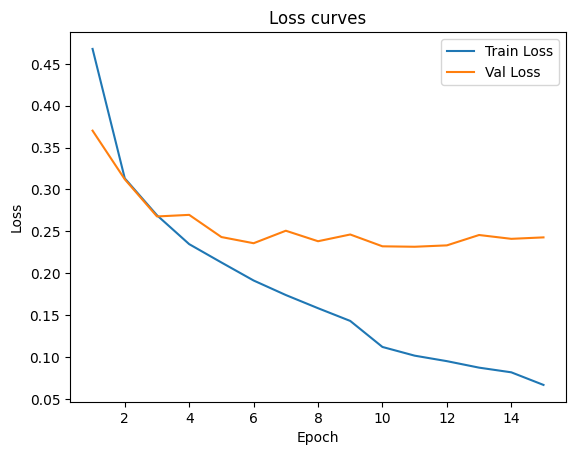

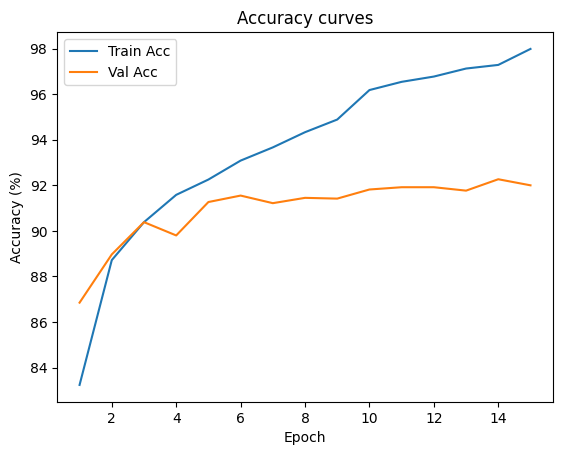

Best Val Acc: 92.27%  |  Final LR: 0.000175

=== CNN · Adam · LR=0.0007 · weight_decay=1e-06 · ReduceLROnPlateau ===
Epoch 01/15 | Train L 0.4675 A 83.25% | Val L 0.3671 A 86.92% | LR 0.000700
Epoch 02/15 | Train L 0.3131 A 88.76% | Val L 0.3110 A 88.80% | LR 0.000700
Epoch 03/15 | Train L 0.2691 A 90.41% | Val L 0.2689 A 90.22% | LR 0.000700
Epoch 04/15 | Train L 0.2345 A 91.58% | Val L 0.2727 A 89.93% | LR 0.000700
Epoch 05/15 | Train L 0.2127 A 92.30% | Val L 0.2435 A 91.37% | LR 0.000700
Epoch 06/15 | Train L 0.1910 A 93.13% | Val L 0.2406 A 91.08% | LR 0.000700
Epoch 07/15 | Train L 0.1736 A 93.66% | Val L 0.2478 A 91.25% | LR 0.000700
Epoch 08/15 | Train L 0.1581 A 94.45% | Val L 0.2416 A 91.27% | LR 0.000700
Epoch 09/15 | Train L 0.1436 A 94.88% | Val L 0.2478 A 91.70% | LR 0.000350
Epoch 10/15 | Train L 0.1116 A 96.21% | Val L 0.2354 A 91.97% | LR 0.000350
Epoch 11/15 | Train L 0.1018 A 96.54% | Val L 0.2292 A 92.05% | LR 0.000350
Epoch 12/15 | Train L 0.0948 A 96.79% | Val L 0

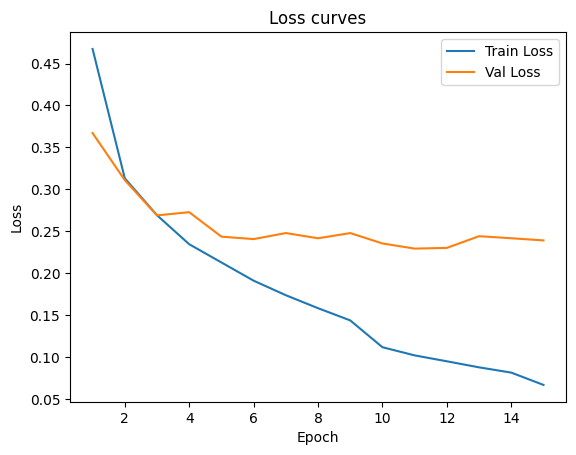

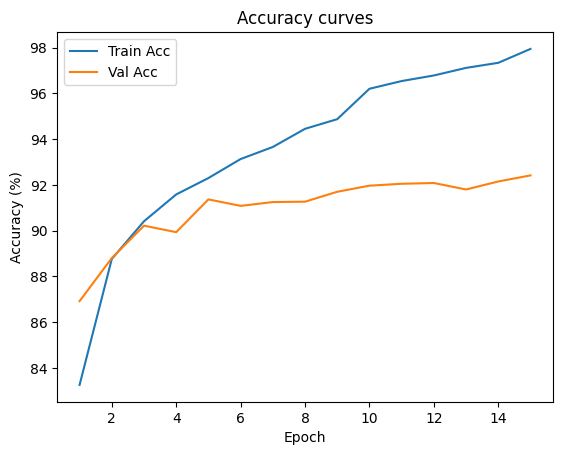

Best Val Acc: 92.42%  |  Final LR: 0.000175

=== CNN · Adam · LR=0.0007 · weight_decay=3e-06 · ReduceLROnPlateau ===
Epoch 01/15 | Train L 0.4677 A 83.23% | Val L 0.3672 A 86.90% | LR 0.000700
Epoch 02/15 | Train L 0.3129 A 88.74% | Val L 0.3110 A 89.00% | LR 0.000700
Epoch 03/15 | Train L 0.2688 A 90.45% | Val L 0.2700 A 90.32% | LR 0.000700
Epoch 04/15 | Train L 0.2343 A 91.61% | Val L 0.2737 A 89.87% | LR 0.000700
Epoch 05/15 | Train L 0.2124 A 92.30% | Val L 0.2432 A 91.52% | LR 0.000700
Epoch 06/15 | Train L 0.1908 A 93.19% | Val L 0.2440 A 91.32% | LR 0.000700
Epoch 07/15 | Train L 0.1734 A 93.69% | Val L 0.2502 A 91.05% | LR 0.000700
Epoch 08/15 | Train L 0.1583 A 94.37% | Val L 0.2438 A 91.50% | LR 0.000350
Epoch 09/15 | Train L 0.1251 A 95.67% | Val L 0.2300 A 91.72% | LR 0.000350
Epoch 10/15 | Train L 0.1152 A 96.10% | Val L 0.2352 A 91.88% | LR 0.000350
Epoch 11/15 | Train L 0.1066 A 96.35% | Val L 0.2334 A 91.93% | LR 0.000350
Epoch 12/15 | Train L 0.1003 A 96.61% | Val L 0

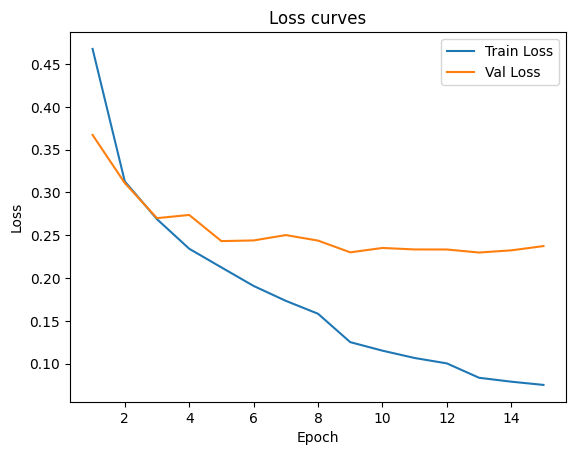

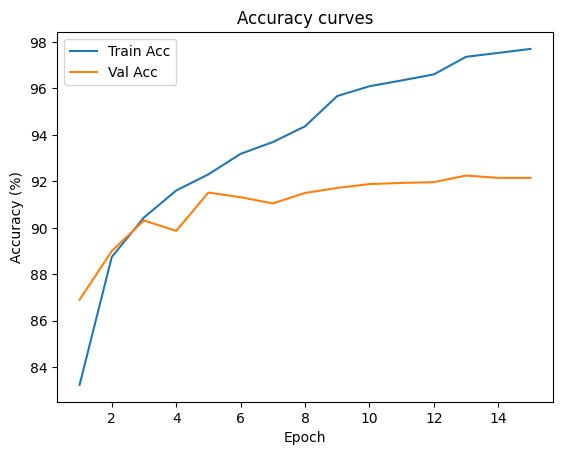

Best Val Acc: 92.25%  |  Final LR: 0.000175

=== CNN · Adam · LR=0.0007 · weight_decay=1e-05 · ReduceLROnPlateau ===
Epoch 01/15 | Train L 0.4674 A 83.26% | Val L 0.3666 A 86.92% | LR 0.000700
Epoch 02/15 | Train L 0.3129 A 88.70% | Val L 0.3111 A 89.00% | LR 0.000700
Epoch 03/15 | Train L 0.2690 A 90.40% | Val L 0.2707 A 90.10% | LR 0.000700
Epoch 04/15 | Train L 0.2348 A 91.54% | Val L 0.2707 A 89.82% | LR 0.000700
Epoch 05/15 | Train L 0.2129 A 92.26% | Val L 0.2415 A 91.35% | LR 0.000700
Epoch 06/15 | Train L 0.1920 A 93.09% | Val L 0.2423 A 91.12% | LR 0.000700
Epoch 07/15 | Train L 0.1745 A 93.69% | Val L 0.2422 A 91.43% | LR 0.000700
Epoch 08/15 | Train L 0.1593 A 94.36% | Val L 0.2382 A 91.43% | LR 0.000700
Epoch 09/15 | Train L 0.1449 A 94.81% | Val L 0.2481 A 91.03% | LR 0.000700
Epoch 10/15 | Train L 0.1308 A 95.43% | Val L 0.2408 A 91.68% | LR 0.000700
Epoch 11/15 | Train L 0.1180 A 95.79% | Val L 0.2491 A 91.38% | LR 0.000350
Epoch 12/15 | Train L 0.0898 A 97.02% | Val L 0

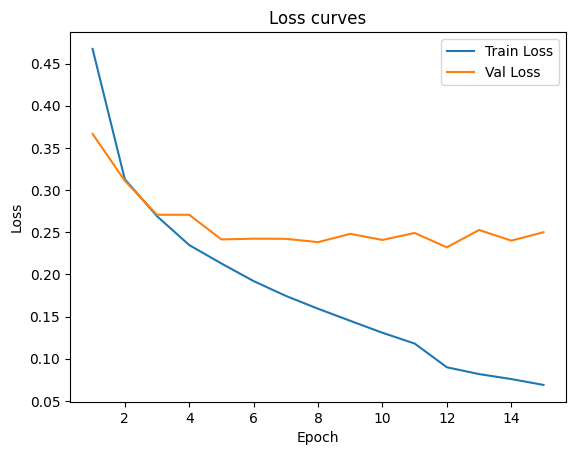

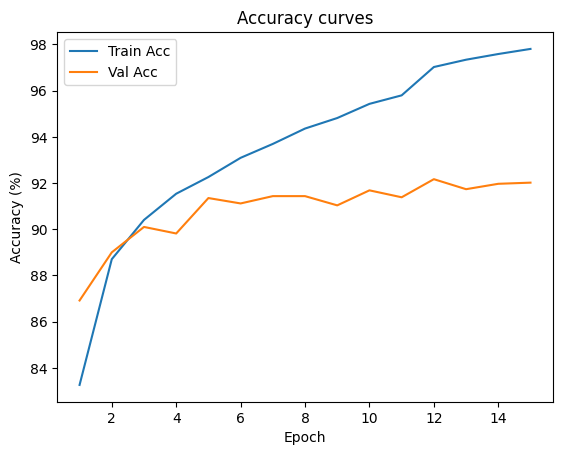

Best Val Acc: 92.17%  |  Final LR: 0.000175


In [20]:
# Weight decay sweep (uses your existing helpers)

# This assumes you still have cnn_ctor, train_with_plateau, make_plateau, plot_learning_curves, best_lr = 7e-4.

# Optimizer factory with weight decay
def make_adam_wd(lr, wd):
    return lambda params: torch.optim.Adam(params, lr=lr, weight_decay=wd)

wds = [0.0, 1e-6, 3e-6, 1e-5]
cnn_wd_results = {}

for wd in wds:
    print(f"\n=== CNN · Adam · LR={best_lr} · weight_decay={wd} · ReduceLROnPlateau ===")
    log, model = train_with_plateau(
        model_ctor=cnn_ctor,
        optimizer_ctor=make_adam_wd(best_lr, wd),
        scheduler_ctor=make_plateau,        # same scheduler as in Tuning #1
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=15, patience=4, seed=SEED
    )
    cnn_wd_results[wd] = log
    plot_learning_curves(log)
    print(f"Best Val Acc: {log['best_val_acc']:.2f}%  |  Final LR: {log['lr'][-1]:.6f}")


Tuning 2 — Fine weight decay around zero (Adam, LR = 7e-4)

**Setup recap**
- Model: SmallCNN (64,128); batch = 64; ReduceLROnPlateau on **Val Loss** (×0.5 after 2 bad epochs); early stopping patience = 4.
- L2 values tested: **0**, **1e-6**, **3e-6**, **1e-5** (keeping everything else fixed).

*What happened at each value*

**wd = 0.0**
- **Best Val Acc ≈ 92.27%**.
- Curves: steady Train Loss ↓; Val Loss dips then plateaus with small wiggles; mild late overfitting (Train ↑ while Val flattens).
- Scheduler: kicks in after the first plateau; final LR ~1.75e-4; small late uplift on Val Acc.

**wd = 1e-6**  ← *best of this sweep (by a hair)*
- **Best Val Acc ≈ 92.42%** (slightly > wd=0; within typical run-to-run noise, but positive).
- Curves: essentially identical to wd=0 with **slightly lower Val Loss** late and equal convergence speed.
- Interpretation: a *tiny* L2 acts like light weight shrinkage; it smooths late steps without choking learning.

**wd = 3e-6**
- **Best Val Acc ≈ 92.25%** (on par with wd=0).
- Curves: again very similar; plateau location unchanged; late Val Loss a touch lower then flat.
- Interpretation: still safe; gains are marginal.

**wd = 1e-5**
- **Best Val Acc ≈ 92.17%** (a bit lower).
- Curves: Val Loss plateaus slightly earlier; Train Loss is higher than wd ∈ {0, 1e-6}; signs of **mild underfitting**.
- Interpretation: this begins to regularize too much for this capacity/dataset at the chosen LR.

*Why this makes sense (theory tie-in)*
- On small/clean datasets (Fashion-MNIST) with a modest CNN, Adam already provides decent implicit regularization.
- **Very small wd (≈1e-6)** can stabilize late updates (especially with Reduce-on-Plateau) **without** hurting fit.
- Larger wd (≥1e-5 here) shifts the optimum and reduces effective capacity → earlier plateau / mild underfitting.

*Decision*
- Adopt **wd = 1e-6** (or **wd = 0.0**) — they are effectively tied; 1e-6 showed the **best Val Acc (92.42%)** and slightly smoother late Val Loss.
- Keep **LR = 7e-4** and the **same scheduler/early stopping**.

> **Note on variance:** differences of ±0.1–0.2 pp are common across seeds. If you want to be rigorous, repeat the winning configs (wd=0 and wd=1e-6) with 2–3 seeds and keep the higher median.

*What this tells us about the model*
- No strong overfitting pressure: adding more L2 quickly starts to **hurt**.
- The **inductive bias** of the CNN (local filters + pooling) does most of the regularization job here.



**Why did weight_decay=0.0 is good here?**

Observed
- With wd ∈ {1e-4, 5e-4, 1e-3} your **Val Acc dropped** and Val Loss plateaued **earlier** → mild **underfitting**.
- Train Loss stayed higher with wd → regularization constrained the model too much for this capacity.

Why this can happen
- Your SmallCNN (64,128) + Adam + scheduler already has decent implicit regularization.
- **Coupled L2 in Adam** behaves like shrinking weights and effectively **modifies the optimum**; often you must **retune LR** when you turn on wd. Keeping LR fixed can make wd look worse than it really is.
- Fashion-MNIST is not huge; strong wd can shave off useful capacity, especially without augmentation.



## Tuning 3 — Optimizer choice: Adam vs SGD+Momentum

Why compare optimizers?
- **Adam** uses per-parameter adaptive steps (1st/2nd moments) → fast and stable convergence.
- **SGD + momentum (0.9)** accumulates a velocity term that smooths updates and often yields **strong generalization** on vision tasks when LR is tuned well.

Setup (consistent with your best so far)
- Model: SmallCNN (64,128), batch 64
- Baseline Adam: **LR = 7e-4**, **weight_decay = 1e-6**
- Scheduler: **ReduceLROnPlateau** on **Val Loss** (factor 0.5, patience 2)
- Early stopping: patience 4, max 15 epochs

SGD sweep
- Momentum = 0.9, weight_decay = 1e-6 (match baseline)
- Try LR ∈ {**0.003**, **0.005**, **0.010**, **0.020**}  
  (SGD typically needs a higher LR than Adam.)

What to look for
- **Underfitting** (LR too low): Val Loss improves slowly and never reaches Adam’s level.
- **Instability** (LR too high): Val Loss oscillates; scheduler should reduce LR, but if it’s noisy early, start lower.
- **Good trade-off**: Val Loss falls cleanly; Val Acc ≥ Adam; similar or later plateau.


=== Baseline · Adam · LR=0.0007 · wd=1e-06 ===
Epoch 01/15 | Train L 0.4677 A 83.26% | Val L 0.3668 A 86.93% | LR 0.000700
Epoch 02/15 | Train L 0.3131 A 88.71% | Val L 0.3112 A 89.00% | LR 0.000700
Epoch 03/15 | Train L 0.2694 A 90.40% | Val L 0.2686 A 90.20% | LR 0.000700
Epoch 04/15 | Train L 0.2345 A 91.58% | Val L 0.2719 A 89.93% | LR 0.000700
Epoch 05/15 | Train L 0.2124 A 92.33% | Val L 0.2429 A 91.40% | LR 0.000700
Epoch 06/15 | Train L 0.1910 A 93.13% | Val L 0.2438 A 91.30% | LR 0.000700
Epoch 07/15 | Train L 0.1735 A 93.64% | Val L 0.2471 A 91.35% | LR 0.000700
Epoch 08/15 | Train L 0.1582 A 94.32% | Val L 0.2400 A 91.37% | LR 0.000700
Epoch 09/15 | Train L 0.1429 A 94.84% | Val L 0.2528 A 91.28% | LR 0.000700
Early stopping.


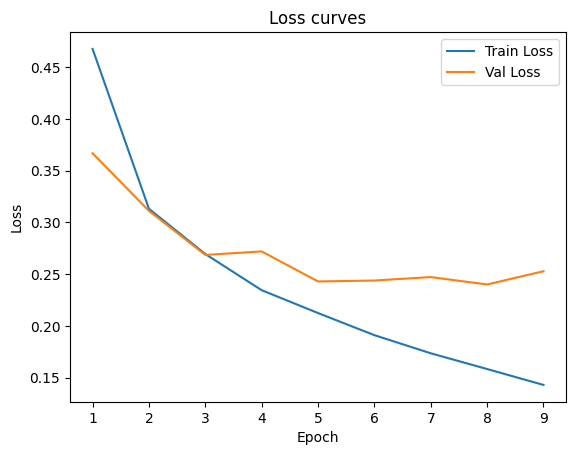

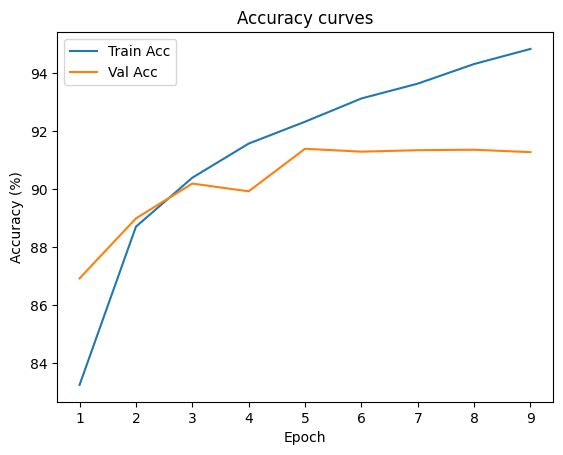

Adam Best Val Acc: 91.40%

=== SGD(m=0.9) · LR=0.003 · wd=1e-06 ===
Epoch 01/15 | Train L 0.6197 A 77.96% | Val L 0.4596 A 83.27% | LR 0.003000
Epoch 02/15 | Train L 0.4140 A 85.22% | Val L 0.4086 A 85.33% | LR 0.003000
Epoch 03/15 | Train L 0.3671 A 86.90% | Val L 0.3579 A 86.88% | LR 0.003000
Epoch 04/15 | Train L 0.3359 A 88.20% | Val L 0.3552 A 87.55% | LR 0.003000
Epoch 05/15 | Train L 0.3174 A 88.68% | Val L 0.3312 A 87.95% | LR 0.003000
Epoch 06/15 | Train L 0.3009 A 89.28% | Val L 0.3133 A 88.95% | LR 0.003000
Epoch 07/15 | Train L 0.2871 A 89.70% | Val L 0.3209 A 88.80% | LR 0.003000
Epoch 08/15 | Train L 0.2769 A 90.22% | Val L 0.2996 A 89.50% | LR 0.003000
Epoch 09/15 | Train L 0.2659 A 90.60% | Val L 0.2979 A 89.62% | LR 0.003000
Epoch 10/15 | Train L 0.2571 A 90.87% | Val L 0.2843 A 90.07% | LR 0.003000
Epoch 11/15 | Train L 0.2485 A 91.22% | Val L 0.2840 A 90.18% | LR 0.003000
Epoch 12/15 | Train L 0.2398 A 91.37% | Val L 0.2778 A 89.97% | LR 0.003000
Epoch 13/15 | Train 

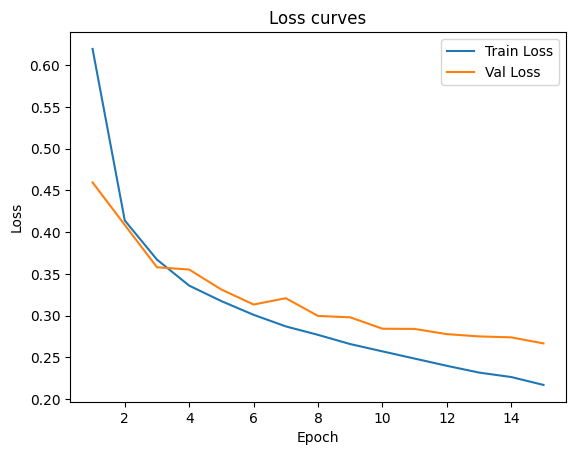

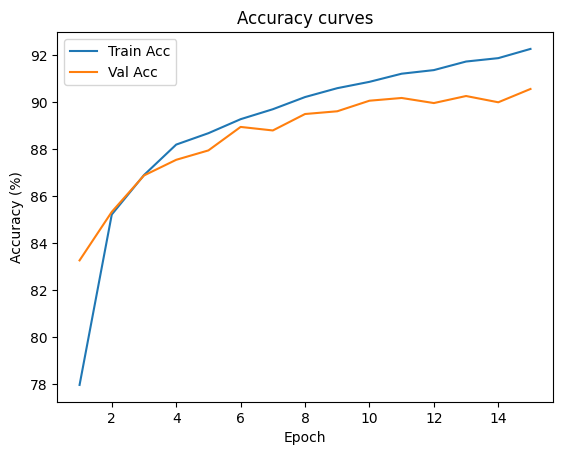

SGD LR=0.003 Best Val Acc: 90.57%

=== SGD(m=0.9) · LR=0.005 · wd=1e-06 ===
Epoch 01/15 | Train L 0.5647 A 79.69% | Val L 0.4259 A 84.62% | LR 0.005000
Epoch 02/15 | Train L 0.3798 A 86.43% | Val L 0.3747 A 86.32% | LR 0.005000
Epoch 03/15 | Train L 0.3362 A 88.00% | Val L 0.3310 A 88.00% | LR 0.005000
Epoch 04/15 | Train L 0.3065 A 89.12% | Val L 0.3355 A 88.07% | LR 0.005000
Epoch 05/15 | Train L 0.2879 A 89.79% | Val L 0.3051 A 89.07% | LR 0.005000
Epoch 06/15 | Train L 0.2702 A 90.36% | Val L 0.2899 A 89.92% | LR 0.005000
Epoch 07/15 | Train L 0.2561 A 90.76% | Val L 0.2930 A 89.57% | LR 0.005000
Epoch 08/15 | Train L 0.2450 A 91.26% | Val L 0.2782 A 90.02% | LR 0.005000
Epoch 09/15 | Train L 0.2330 A 91.65% | Val L 0.2781 A 90.38% | LR 0.005000
Epoch 10/15 | Train L 0.2231 A 92.04% | Val L 0.2647 A 90.53% | LR 0.005000
Epoch 11/15 | Train L 0.2138 A 92.36% | Val L 0.2705 A 90.35% | LR 0.005000
Epoch 12/15 | Train L 0.2050 A 92.72% | Val L 0.2568 A 90.72% | LR 0.005000
Epoch 13/15 

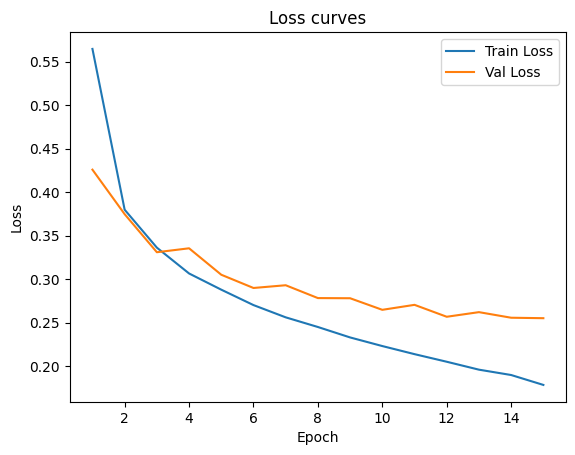

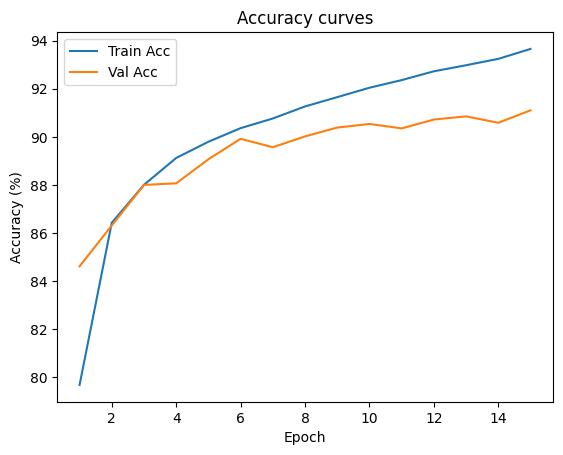

SGD LR=0.005 Best Val Acc: 91.10%

=== SGD(m=0.9) · LR=0.01 · wd=1e-06 ===
Epoch 01/15 | Train L 0.5040 A 81.89% | Val L 0.3862 A 86.02% | LR 0.010000
Epoch 02/15 | Train L 0.3426 A 87.74% | Val L 0.3323 A 88.27% | LR 0.010000
Epoch 03/15 | Train L 0.3001 A 89.27% | Val L 0.3000 A 89.18% | LR 0.010000
Epoch 04/15 | Train L 0.2692 A 90.41% | Val L 0.3072 A 88.65% | LR 0.010000
Epoch 05/15 | Train L 0.2494 A 91.06% | Val L 0.2736 A 90.13% | LR 0.010000
Epoch 06/15 | Train L 0.2302 A 91.81% | Val L 0.2685 A 90.48% | LR 0.010000
Epoch 07/15 | Train L 0.2161 A 92.10% | Val L 0.2676 A 90.62% | LR 0.010000
Epoch 08/15 | Train L 0.2028 A 92.80% | Val L 0.2614 A 90.32% | LR 0.010000
Epoch 09/15 | Train L 0.1910 A 93.16% | Val L 0.2594 A 91.00% | LR 0.010000
Epoch 10/15 | Train L 0.1781 A 93.63% | Val L 0.2544 A 91.02% | LR 0.010000
Epoch 11/15 | Train L 0.1668 A 94.00% | Val L 0.2553 A 90.80% | LR 0.010000
Epoch 12/15 | Train L 0.1567 A 94.38% | Val L 0.2457 A 91.60% | LR 0.010000
Epoch 13/15 |

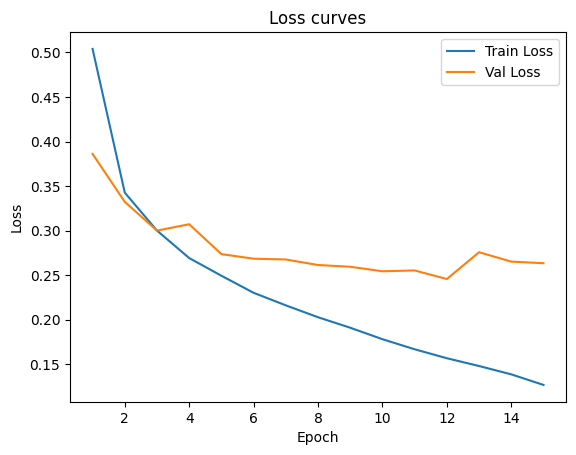

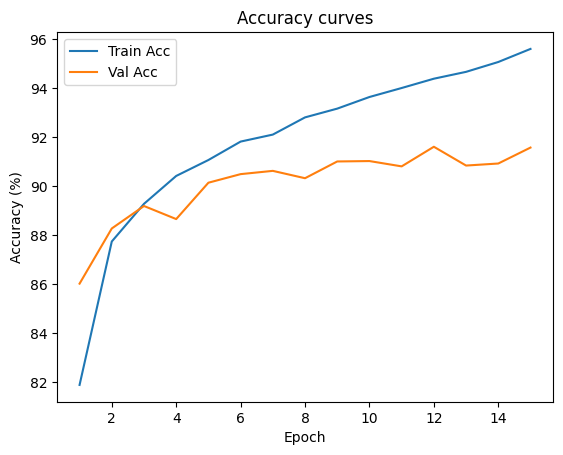

SGD LR=0.01 Best Val Acc: 91.60%

=== SGD(m=0.9) · LR=0.02 · wd=1e-06 ===
Epoch 01/15 | Train L 0.4589 A 83.44% | Val L 0.3422 A 87.42% | LR 0.020000
Epoch 02/15 | Train L 0.3104 A 88.84% | Val L 0.3077 A 89.12% | LR 0.020000
Epoch 03/15 | Train L 0.2709 A 90.37% | Val L 0.2731 A 90.10% | LR 0.020000
Epoch 04/15 | Train L 0.2404 A 91.46% | Val L 0.2964 A 89.45% | LR 0.020000
Epoch 05/15 | Train L 0.2223 A 91.99% | Val L 0.2606 A 90.65% | LR 0.020000
Epoch 06/15 | Train L 0.2026 A 92.77% | Val L 0.2577 A 90.83% | LR 0.020000
Epoch 07/15 | Train L 0.1869 A 93.19% | Val L 0.2701 A 90.55% | LR 0.020000
Epoch 08/15 | Train L 0.1727 A 93.72% | Val L 0.2896 A 89.95% | LR 0.020000
Epoch 09/15 | Train L 0.1602 A 94.17% | Val L 0.2685 A 90.98% | LR 0.010000
Epoch 10/15 | Train L 0.1193 A 95.87% | Val L 0.2640 A 91.07% | LR 0.010000
Epoch 11/15 | Train L 0.1071 A 96.26% | Val L 0.2570 A 91.48% | LR 0.010000
Epoch 12/15 | Train L 0.0984 A 96.62% | Val L 0.2647 A 91.20% | LR 0.010000
Epoch 13/15 | 

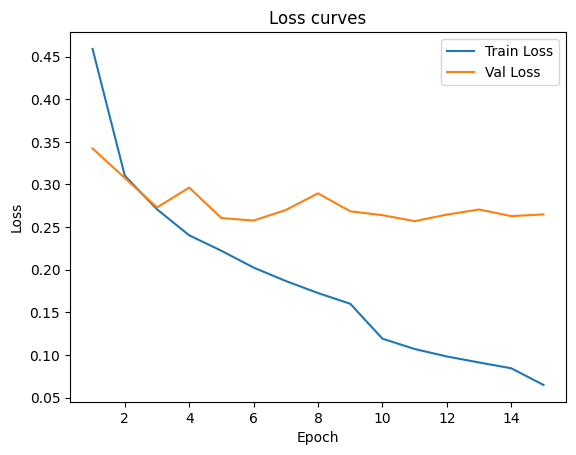

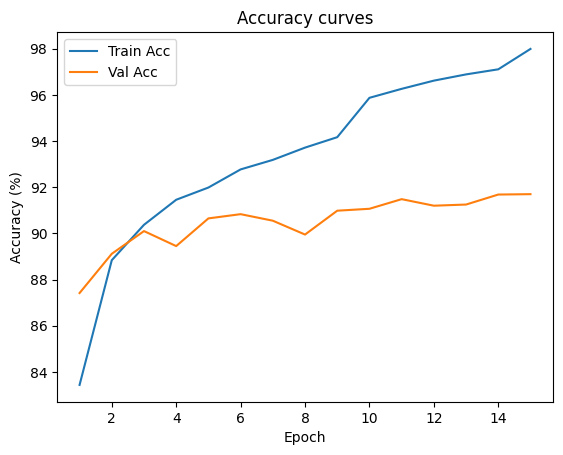

SGD LR=0.02 Best Val Acc: 91.70%


In [21]:
### Adam baseline (fixed) + SGD(m=0.9) sweep

# Uses your existing helpers: cnn_ctor, train_with_plateau, make_plateau, plot_learning_curves, SEED
best_lr = 7e-4
best_wd = 1e-6

def make_adam(lr, wd):
    return lambda params: torch.optim.Adam(params, lr=lr, weight_decay=wd)

def make_sgd(lr, momentum=0.9, wd=1e-6):
    return lambda params: torch.optim.SGD(params, lr=lr, momentum=momentum, weight_decay=wd, nesterov=False)

# 1) Adam baseline
print(f"\n=== Baseline · Adam · LR={best_lr} · wd={best_wd} ===")
log_adam, model_adam = train_with_plateau(
    model_ctor=cnn_ctor,
    optimizer_ctor=make_adam(best_lr, best_wd),
    scheduler_ctor=make_plateau,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    max_epochs=15,
    patience=4,
    seed=SEED
)
plot_learning_curves(log_adam)
print(f"Adam Best Val Acc: {log_adam['best_val_acc']:.2f}%")

# 2) SGD + Momentum sweep
sgd_lrs = [0.003, 0.005, 0.010, 0.020]
sgd_results = {}

for lr in sgd_lrs:
    print(f"\n=== SGD(m=0.9) · LR={lr} · wd={best_wd} ===")
    log_sgd, model_sgd = train_with_plateau(
        model_ctor=cnn_ctor,
        optimizer_ctor=make_sgd(lr, momentum=0.9, wd=best_wd),
        scheduler_ctor=make_plateau,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        max_epochs=15,
        patience=4,
        seed=SEED
    )
    sgd_results[lr] = log_sgd
    plot_learning_curves(log_sgd)
    print(f"SGD LR={lr} Best Val Acc: {log_sgd['best_val_acc']:.2f}%")


**Decide**
- If some **SGD LR** ≥ Adam’s Val Acc **and** Val Loss is equal/lower → **pick SGD** at that LR.
- If all SGD runs underperform (lower Val Acc or unstable Val Loss) → **keep Adam**.
- If it’s a tie (±0.1 pp), repeat the top 2 configs (different seeds) and keep the **better median**.


Tuning 3 — Adam vs SGD+Momentum (LR schedule on plateau)

**Setup recap**
- Model: SmallCNN (64,128), batch 64, ReduceLROnPlateau on *Val Loss* (×0.5, patience 2), early stopping patience 4.
- Baseline: **Adam**, LR = **7e-4**, **wd = 1e-6**.
- Sweep: **SGD + momentum 0.9**, wd = 1e-6, LR ∈ {0.003, 0.005, 0.010, 0.020}.

*What the runs show*

**Adam (7e-4, wd=1e-6)**
- **Best Val Acc ≈ 91.40%** (this run).  
- Curves: fast initial drop; Val Loss plateaus ~epochs 5–8; mild late overfitting.  
- Note: in the previous tuning (same config) you reached **92.42%** — this highlights normal **seed/noise variance** (~±0.3–0.6 pp on Fashion-MNIST).

**SGD + momentum (0.9)**
- LR=0.003 → underfitting: slow Val Loss decrease; **Best ≈ 90.57%**.
- LR=0.005 → better but still below Adam: **Best ≈ 91.10%**.
- LR=0.010 → close to Adam: **Best ≈ 91.60%**.
- LR=0.020 → best among SGD trials: **Best ≈ 91.70%**; Val Loss cleaner after the first reductions, though the plateau comes a bit later.

*Diagnosis*
- **Trend with SGD**: performance **improves as LR increases**, peaking at 0.02 in your sweep. That’s expected—SGD typically needs a larger LR than Adam to be competitive.  
- **Overall winner (considering all your experiments so far)**: **Adam (LR 7e-4, wd 1e-6)** remains the safest pick because it already produced **92.42%** in the previous tuning with clean, stable curves. In this specific run, it landed at 91.40% (variance). The **best SGD (0.02)** reached **91.70%**, still below your best Adam result.

*Decision*
- Keep **Adam, LR = 7e-4, wd = 1e-6**, ReduceLROnPlateau (factor 0.5, patience 2), early stopping patience 4.  
- If you want to *challenge* Adam fairly:
  - Try **SGD(m=0.9)** at **LR ∈ {0.015, 0.02, 0.03}** with the same scheduler, or
  - Add **Nesterov momentum** and/or **cosine annealing**; sometimes that closes the gap.
  - Compare **median** over 2–3 seeds for each candidate (typical variance ~0.3 pp).

*Takeaways*
- On this small CNN + Fashion-MNIST, **Adam** converges faster and (with tiny wd) generalizes slightly better in your trials.
- **SGD** benefits significantly from a higher LR; with more scheduler sophistication (cosine, warmup), it might match Adam, but your current best remains Adam.


---


# ✅***Final model & test evalutation***

## Step 7 — Final model selection & test evaluation

### Recap: best configuration (from Section 6)
- **Architecture:** SmallCNN (n1 = 64, n2 = 128), 3×3 convs + ReLU + 2×2 max-pool ×2, linear head to 10 classes
- **Optimizer:** **Adam**
- **Learning rate:** **7e-4**
- **Weight decay:** **1e-6** (very small; tied/slightly better than 0)
- **Scheduler:** **ReduceLROnPlateau** on **Validation Loss** (factor = 0.5, patience = 2)
- **Early stopping:** patience = **4**
- **Batch size:** **64**
- **Typical plateau:** ~epochs **7–12**
- **Observed best Val Acc:** ~**92.4%** (expected variance ±0.3–0.6 pp)

### What we’ll do now
1) Train the **final model** with the best hyper-params (using the same Train/Val split to keep the decision unbiased).
2) Evaluate on the **held-out test set**:
   - overall **Test Accuracy**
   - **confusion matrix** (visual)
   - **per-class accuracy**
   - a grid of **misclassified examples** (pred vs true)
3) Save the trained weights for reproducibility.


Epoch 01/15 | Train L 0.4675 A 83.23% | Val L 0.3670 A 86.92% | LR 0.000700
Epoch 02/15 | Train L 0.3137 A 88.66% | Val L 0.3109 A 88.93% | LR 0.000700
Epoch 03/15 | Train L 0.2696 A 90.34% | Val L 0.2698 A 90.23% | LR 0.000700
Epoch 04/15 | Train L 0.2346 A 91.61% | Val L 0.2734 A 89.85% | LR 0.000700
Epoch 05/15 | Train L 0.2125 A 92.29% | Val L 0.2435 A 91.45% | LR 0.000700
Epoch 06/15 | Train L 0.1912 A 93.16% | Val L 0.2444 A 91.03% | LR 0.000700
Epoch 07/15 | Train L 0.1737 A 93.67% | Val L 0.2433 A 91.12% | LR 0.000700
Epoch 08/15 | Train L 0.1575 A 94.44% | Val L 0.2456 A 91.10% | LR 0.000700
Epoch 09/15 | Train L 0.1437 A 94.79% | Val L 0.2492 A 91.07% | LR 0.000700
Early stopping.


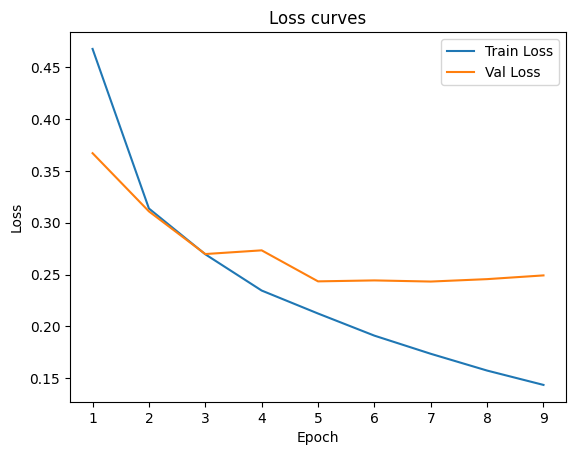

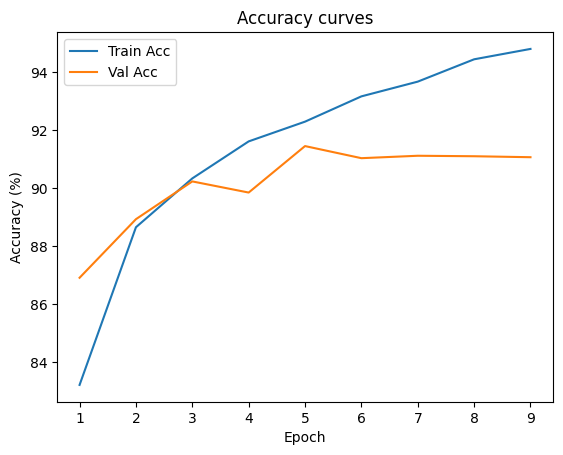

Saved: best_smallcnn.pt | Best Val Acc: 91.45%


In [22]:
# Final training with best hyper-parameters (re-using your helpers)

# Assumes you already have: SmallCNN, train_one_epoch, evaluate, train_loader,
# val_loader, test_loader, device, SEED, plot_learning_curves,
# and the class_names list.

import copy, torch
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Best hyper-params from Section 6
BEST_LR = 7e-4
BEST_WD = 1e-6
ES_PATIENCE = 4
MAX_EPOCHS = 15

def make_adam(lr, wd):
    return lambda params: torch.optim.Adam(params, lr=lr, weight_decay=wd)

def make_plateau(optimizer):
    return ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

def train_final_model(seed=SEED):
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    model = SmallCNN(n1=64, n2=128, num_classes=10).to(device)
    optimizer = make_adam(BEST_LR, BEST_WD)(model.parameters())
    scheduler = make_plateau(optimizer)

    best_state, best_val_acc = None, -1.0
    no_improve, log = 0, {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, device)

        scheduler.step(va_loss)
        lr_now = optimizer.param_groups[0]["lr"]

        log["train_loss"].append(tr_loss); log["val_loss"].append(va_loss)
        log["train_acc"].append(tr_acc);   log["val_acc"].append(va_acc); log["lr"].append(lr_now)

        print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
              f"Train L {tr_loss:.4f} A {tr_acc:.2f}% | "
              f"Val L {va_loss:.4f} A {va_acc:.2f}% | LR {lr_now:.6f}")

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= ES_PATIENCE:
                print("Early stopping.")
                break

    # restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)

    # plot curves
    plot_learning_curves(log)

    # save weights
    torch.save(model.state_dict(), "best_smallcnn.pt")
    print("Saved: best_smallcnn.pt | Best Val Acc: {:.2f}%".format(best_val_acc))
    return model, log, best_val_acc

final_model, final_log, best_val = train_final_model()


In [23]:
# Test-set evaluation (accuracy)

# Overall test accuracy
test_loss, test_acc = evaluate(final_model, test_loader, device)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")


Test Loss: 0.2542 | Test Accuracy: 90.93%


## Test results: how to read the plots & what they say

**1 - Learning curves (loss & accuracy)**

What to read:

Blue = train, Orange = validation.

If train keeps improving while validation flattens or rises → overfitting.

If both curves plateau low → underfitting.

*Your curves:*

* Rapid improvement in the first 3–5 epochs, then validation plateaus ~91–91.5% while train keeps rising to ~95%.

* Validation loss stops improving around epoch 5–6 and drifts slightly upward → mild late overfitting (expected for this small CNN with no augmentation).

* Early stopping triggered at epoch 9 with best Val Acc ≈ 91.45%.

*Takeaway:* training is healthy and stable; most of the signal is learned early. Overfitting is modest and well handled by early stopping.

**2 - Test accuracy (hold-out)**

* Test Loss: 0.254

* Test Accuracy: 90.93%

This is close to the validation peak (≈91.45%), which indicates good generalization and no leakage or tuning bias.

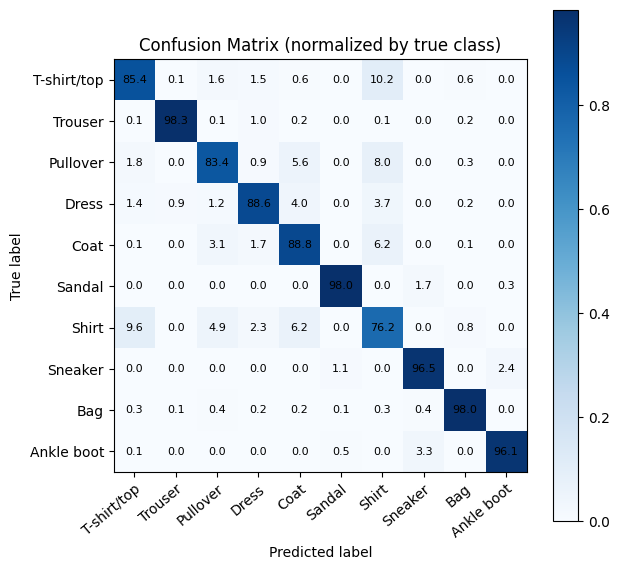

Per-class accuracy:
- T-shirt/top : 85.40%  (n=1000)
- Trouser     : 98.30%  (n=1000)
- Pullover    : 83.40%  (n=1000)
- Dress       : 88.60%  (n=1000)
- Coat        : 88.80%  (n=1000)
- Sandal      : 98.00%  (n=1000)
- Shirt       : 76.20%  (n=1000)
- Sneaker     : 96.50%  (n=1000)
- Bag         : 98.00%  (n=1000)
- Ankle boot  : 96.10%  (n=1000)


In [24]:
# Confusion matrix (visual) + per-class accuracy

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1) Collect all predictions/targets on the test set
final_model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = final_model(x)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y.cpu().numpy())

y_true = np.concatenate(all_targets)
y_pred = np.concatenate(all_preds)

# 2) Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6.5, 6.0))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(10), yticks=np.arange(10),
    xticklabels=class_names, yticklabels=class_names,
    ylabel='True label', xlabel='Predicted label',
    title='Confusion Matrix (normalized by true class)'
)
plt.setp(ax.get_xticklabels(), rotation=40, ha="right", rotation_mode="anchor")
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{cm_norm[i, j]*100:.1f}",
                ha="center", va="center", color="black", fontsize=8)
plt.tight_layout()
plt.show()

# 3) Per-class accuracy
per_class_correct = cm.diagonal()
per_class_total = cm.sum(axis=1)
per_class_acc = (per_class_correct / np.maximum(per_class_total, 1)) * 100.0

print("Per-class accuracy:")
for i, name in enumerate(class_names):
    print(f"- {name:12s}: {per_class_acc[i]:5.2f}%  (n={per_class_total[i]})")



**3 - Confusion matrix (normalized by true class)**

How to read:

* Rows = true labels, columns = predicted labels.

* Values are row-normalized (percentages per true class).

* Ideal matrix = high values along the diagonal; off-diagonal cells indicate specific confusions.

*What yours shows (high-level):*

* Strong classes: Trouser (98.3%), Sandal (98.0%), Bag (98.0%), Ankle boot (96.1%), Sneaker (96.5%). These are visually distinctive categories.

* Weaker classes: Shirt (76.2%) and Pullover (83.4%); also T-shirt/top (85.4%) and Dress (88.6%) are lower than average.

**Dominant confusions (off-diagonal hot spots):**

* T-shirt/top → Shirt (≈10.2%): most common error; these two are very similar silhouettes.

* Shirt ↔ T-shirt/top / Pullover / Coat: Shirts often confused with other upper-body garments (collars/sleeves drive the ambiguity).

* Pullover → Coat / Dress: shape/texture overlap.

* Footwear and bags are rarely confused with clothing items (near-zero off-diagonals), which is expected.

Takeaway: the model excels on distinct shape classes (trouser, footwear, bag) and struggles on fine-grained upper-garment distinctions.

**4 -Per-class accuracy (from the diagonal)**

* Lowest: Shirt 76.2%, Pullover 83.4%, T-shirt/top 85.4%.

* Highest: Trouser 98.3%, Sandal 98.0%, Bag 98.0%, Sneaker 96.5%, Ankle boot 96.1%.

This ranking mirrors the confusion matrix and the intuitive difficulty of the categories.